In [1]:
# importing the libraries

import pandas as pd
import seaborn as sns 
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_auc_score, mean_absolute_error, mean_squared_error
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.preprocessing import RobustScaler
import scipy.stats as stats

np.random.seed(42)
random.seed(42)

# Importing and splitting the data into training and testing

In [2]:
df = pd.read_excel('./lebanon_data.xlsx', sheet_name="Data Values")

# check row counts after split
total_rows = len(df)

print(f"Total rows: {total_rows}")

Total rows: 352


c:\Users\gamin\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


# Exploratory data analysis

# Pre processing Dataset

In [3]:
df.head(15)

,Study_type,StudyID,Appropriate_antibiotics,Antibiotic1,Antibiotic2,Antibiotic3,Antibiotic4,BMT,Ageyears,Sex,...,FiO2,BilirubinTotal,PT,PTT,INR,Cortisol_level,Troponin_cat,Lactate_cat,SBP_presentation_cat,Bacteremic
0,0,404,NaN,NaN,NaN,NaN,NaN,NaN,70-80,1,...,NaN,2.0,20.1,24.5,1.8,NaN,NaN,0.0,1,0
1,0,403,1.0,NaN,Meropenum,Tazocin,Amikacin,NaN,70-80,1,...,21.0,NaN,70.0,NaN,6.0,NaN,NaN,1.0,1,1
2,0,402,NaN,NaN,NaN,NaN,NaN,NaN,50-60,0,...,NaN,NaN,49.3,NaN,4.0,NaN,NaN,NaN,0,0
3,0,401,NaN,NaN,NaN,NaN,NaN,NaN,70-80,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0
4,0,400,1.0,NaN,NaN,Tazocin,Levofloxacin,NaN,80-90,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,1
5,0,399,NaN,NaN,NaN,NaN,NaN,NaN,50-60,1,...,100.0,10.3,27.8,50.0,2.4,NaN,NaN,NaN,0,0
6,0,397,NaN,NaN,NaN,NaN,NaN,NaN,40-50,0,...,21.0,0.6,27.7,153.0,2.4,NaN,NaN,0.0,1,0
7,0,396,1.0,NaN,Meropenum,Amikacin,NaN,NaN,60-70,0,...,40.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1,1
8,0,393,NaN,NaN,NaN,NaN,NaN,NaN,>90,1,...,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0
9,0,392,NaN,NaN,NaN,NaN,NaN,NaN,70-80,0,...,60.0,1.3,13.6,40.0,1.2,NaN,NaN,0.0,0,0


As can be seen, this is a time series data. The dataframe has 44 columns. After the first loook at data, it can be observed that the data seems quite sparse.

In [4]:
# let's list down all the different columns
df.columns

Index(['Study_type', 'StudyID', 'Appropriate_antibiotics', 'Antibiotic1',
       'Antibiotic2', 'Antibiotic3', 'Antibiotic4', 'BMT', 'Ageyears', 'Sex',
       ...
       'FiO2', 'BilirubinTotal', 'PT', 'PTT', 'INR', 'Cortisol_level',
       'Troponin_cat', 'Lactate_cat', 'SBP_presentation_cat', 'Bacteremic'],
      dtype='str', length=149)

In [5]:
# Function to draw correlation heat map 

def corr_matrix(df):
  corr = df.corr()
  mask = np.triu(np.ones_like(corr, dtype=bool))
  f, ax = plt.subplots(figsize=(40,40))
  cmap = sns.diverging_palette(220, 10, as_cmap=True)
  sns.heatmap(corr, mask=mask, cmap="Paired", vmax=.3, center=0,
              square=True, linewidths=.5, cbar_kws={"shrink": .5})

## Data Cleaning

In [6]:
null_values = df.isnull().mean()*100
null_values = null_values.sort_values(ascending=False)
columns_drop = null_values[null_values >= 25].index.tolist()
print(columns_drop)

['gram_neg_bacilli_blood', 'gram_neg_bacilli_urine', 'gram_neg_bacilli_wound', 'streptococcus_other', 'klebsiella_other', 'gram_neg_bacilli_sputum', 'Active_Cancer_type3', 'clostridium_species_urine', 'clostridium_species_wound', 'clostridium_sputum', 'Other_medical_history', 'Cancer_Remission_type2', 'Cortisol_level', 'enterococcus_wound', 'enterococcus_sputum', 'Active_Cancer_type2', 'proteus_mirabilis_wound', 'streptococcus_wound', 'streptococcus_urine', 'Antibiotic4', 'Cancer_Remission_type1', 'BMT', 'Name_other_type_infection', 'Troponin_cat', 'CKMB', 'Antibiotic3', 'Antibiotic1', 'Steroid_type', 'Troponin', 'Antibiotic2', 'Appropriate_antibiotics', 'BilirubinTotal', 'Time_to_vasopressors_inotropes_withinfirst_24hours', 'Vasopressors_inotropes_Treatment_Duration_withinfirst_24hours', 'EF_non_EF_control', 'prevotella', 'Active_Cancer_type1_cat', 'gram_neg_bacilli', 'Streptococcus_species_name', 'Tumors_type', 'propionibacterium', 'Hospital_LOS_days_onlysurvived_multivariate', 'Loca

In [7]:
# the features have been removed based that have more than 25% null values
df_train_mod = df.drop(columns=columns_drop)

# Drop String and code features
df_train_mod = df_train_mod.drop(
    columns=[
        "StudyID",
        "Study_type",
        "Site_of_infection",
        "Code",
        "Cancer_in_remission",
        "Diagnosis",
        "DCHome",
        "Antibiotics_Initiated_ED",
        "Antibiotics_Initiated_ICU",
        "ICU_LOS_days",
        "GPU_LOS_days",
        "Hospital_LOS_days",
        "ICU_LOS_hours",
        "GPU_LOS_hours",
        "Hospital_LOS_hours",
        "ED_Length_of_Stay_LOS_hours",
        "Admission_to_hospital",
        "Antibiotics_Used",
        "Undergone_chemotherapy",
        "Undergone_radiation_therapy",
        "Undergone_surgical_therapy",
        "ICU_GPU_admission",
        "ICU_Admission",
        "GPU_Admission",
        "ED_Disposition",
    ]
)

# Drop correlated features automatically
corr_threshold = 0.9

numeric_cols = df_train_mod.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != "Active_cancer"]

corr = df_train_mod[numeric_cols].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

cols_to_drop = [col for col in upper.columns if any(upper[col] > corr_threshold)]
print("Dropped correlated features:", cols_to_drop)

df_train_mod = df_train_mod.drop(columns=cols_to_drop)

df_train_mod.columns

Dropped correlated features: ['MAP_Upon_presentation_ED', 'MAP_6hours', 'Hematocrit']


Index(['Ageyears', 'Sex', 'SystolicCHF_EF_less_than40',
       'Non_SystolicCHF_EF≥40', 'DM', 'CAD', 'HTN',
       'CerebrovascularaccidentsCVA', 'ChronickidneydiseaseCKDonHD',
       'COPD_Emphysema', 'Active_cancer', 'Staphylococcus_Aureus',
       'Staph_coagulase_negative', 'Pseudomonas', 'Enterococcus_species',
       'Streptococcus_species', 'E.Coli', 'Klebsiella_pneumoniae',
       'Proteus_mirabilis', 'Clostridium_species', 'Acinetobacter_baumani',
       'Other_type_infection', 'Mortality_72hours', 'Mortality_28days',
       'Mortality_60days', 'Expired_at_hospital_during_this_admission',
       'Vasopressors_use_Levophed', 'Vasopressors_use_Dopamine',
       'Inotrope_use_Dobutamine',
       'Patient_receive_vasopressors_inotropes_withinfirst_24h',
       'Steroids_Use', 'Time_to_Antibiotic_treatment_initiation_hours',
       'Antibiotics_Initiated_GPU', 'IVfluids_requirement_first_6hrs',
       'IVfluids_requirement_first_24hrs', 'SBP_Upon_presentation_ED',
       'DBP_Upon_

In [8]:
# Format the Age

def parse_ageyears(value):
    if pd.isna(value):
        return np.nan

    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)

    text = str(value).strip()
    if "-" in text:
        low, high = text.split("-", 1)
        return (float(low) + float(high)) / 2

    return pd.to_numeric(text, errors="coerce")

df_train_mod["Ageyears"] = df_train_mod["Ageyears"].apply(parse_ageyears).astype(float)

In [9]:
# Format the mortality label based on Mortality_28days only
def create_mortality_label(row):
    return int(row["Mortality_28days"] == 1)

df_train_mod["Mortality"] = df_train_mod.apply(create_mortality_label, axis=1)

# Drop original mortality columns
df_train_mod = df_train_mod.drop(
    columns=[
        "Mortality_28days",
        "Mortality_72hours",
        "Mortality_60days",
        "Expired_at_hospital_during_this_admission"
    ]
)

In [10]:
df_train_mod

,Ageyears,Sex,SystolicCHF_EF_less_than40,Non_SystolicCHF_EF≥40,DM,CAD,HTN,CerebrovascularaccidentsCVA,ChronickidneydiseaseCKDonHD,COPD_Emphysema,...,Bicarbonate,Chloride,BodyUreaNitrogen,Creatinine,Calcium,Phosphate,Magnesium,SBP_presentation_cat,Bacteremic,Mortality
0,75.0,1,1,0,0,1,1,0,0,0,...,17.0,103,42.0,1.9,8.0,2.8,2.3,1,0,0
1,75.0,1,0,1,1,1,1,0,0,0,...,24.0,89,44.0,1.6,9.2,2.2,1.4,1,1,0
2,55.0,0,0,0,1,1,0,0,1,0,...,16.0,99,69.0,12.0,9.4,11.3,2.7,0,0,0
3,75.0,1,0,0,1,0,1,0,0,1,...,32.0,89,30.0,0.7,9.4,2.2,1.6,1,0,0
4,85.0,1,0,1,0,0,1,0,0,0,...,20.0,95,50.0,2.1,8.3,3.5,1.9,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347,55.0,0,0,1,0,0,0,0,0,0,...,15.0,107,22.0,1.1,8.3,2.9,1.6,1,1,0
348,55.0,1,0,1,0,0,0,0,0,0,...,25.0,95,38.0,1.8,7.1,3.6,1.2,0,1,0
349,65.0,1,0,1,0,0,0,0,0,0,...,14.0,105,23.0,1.1,6.0,0.6,1.2,1,1,1
350,65.0,0,0,0,1,0,1,0,0,0,...,22.0,101,25.0,0.9,6.5,3.2,1.0,0,1,1


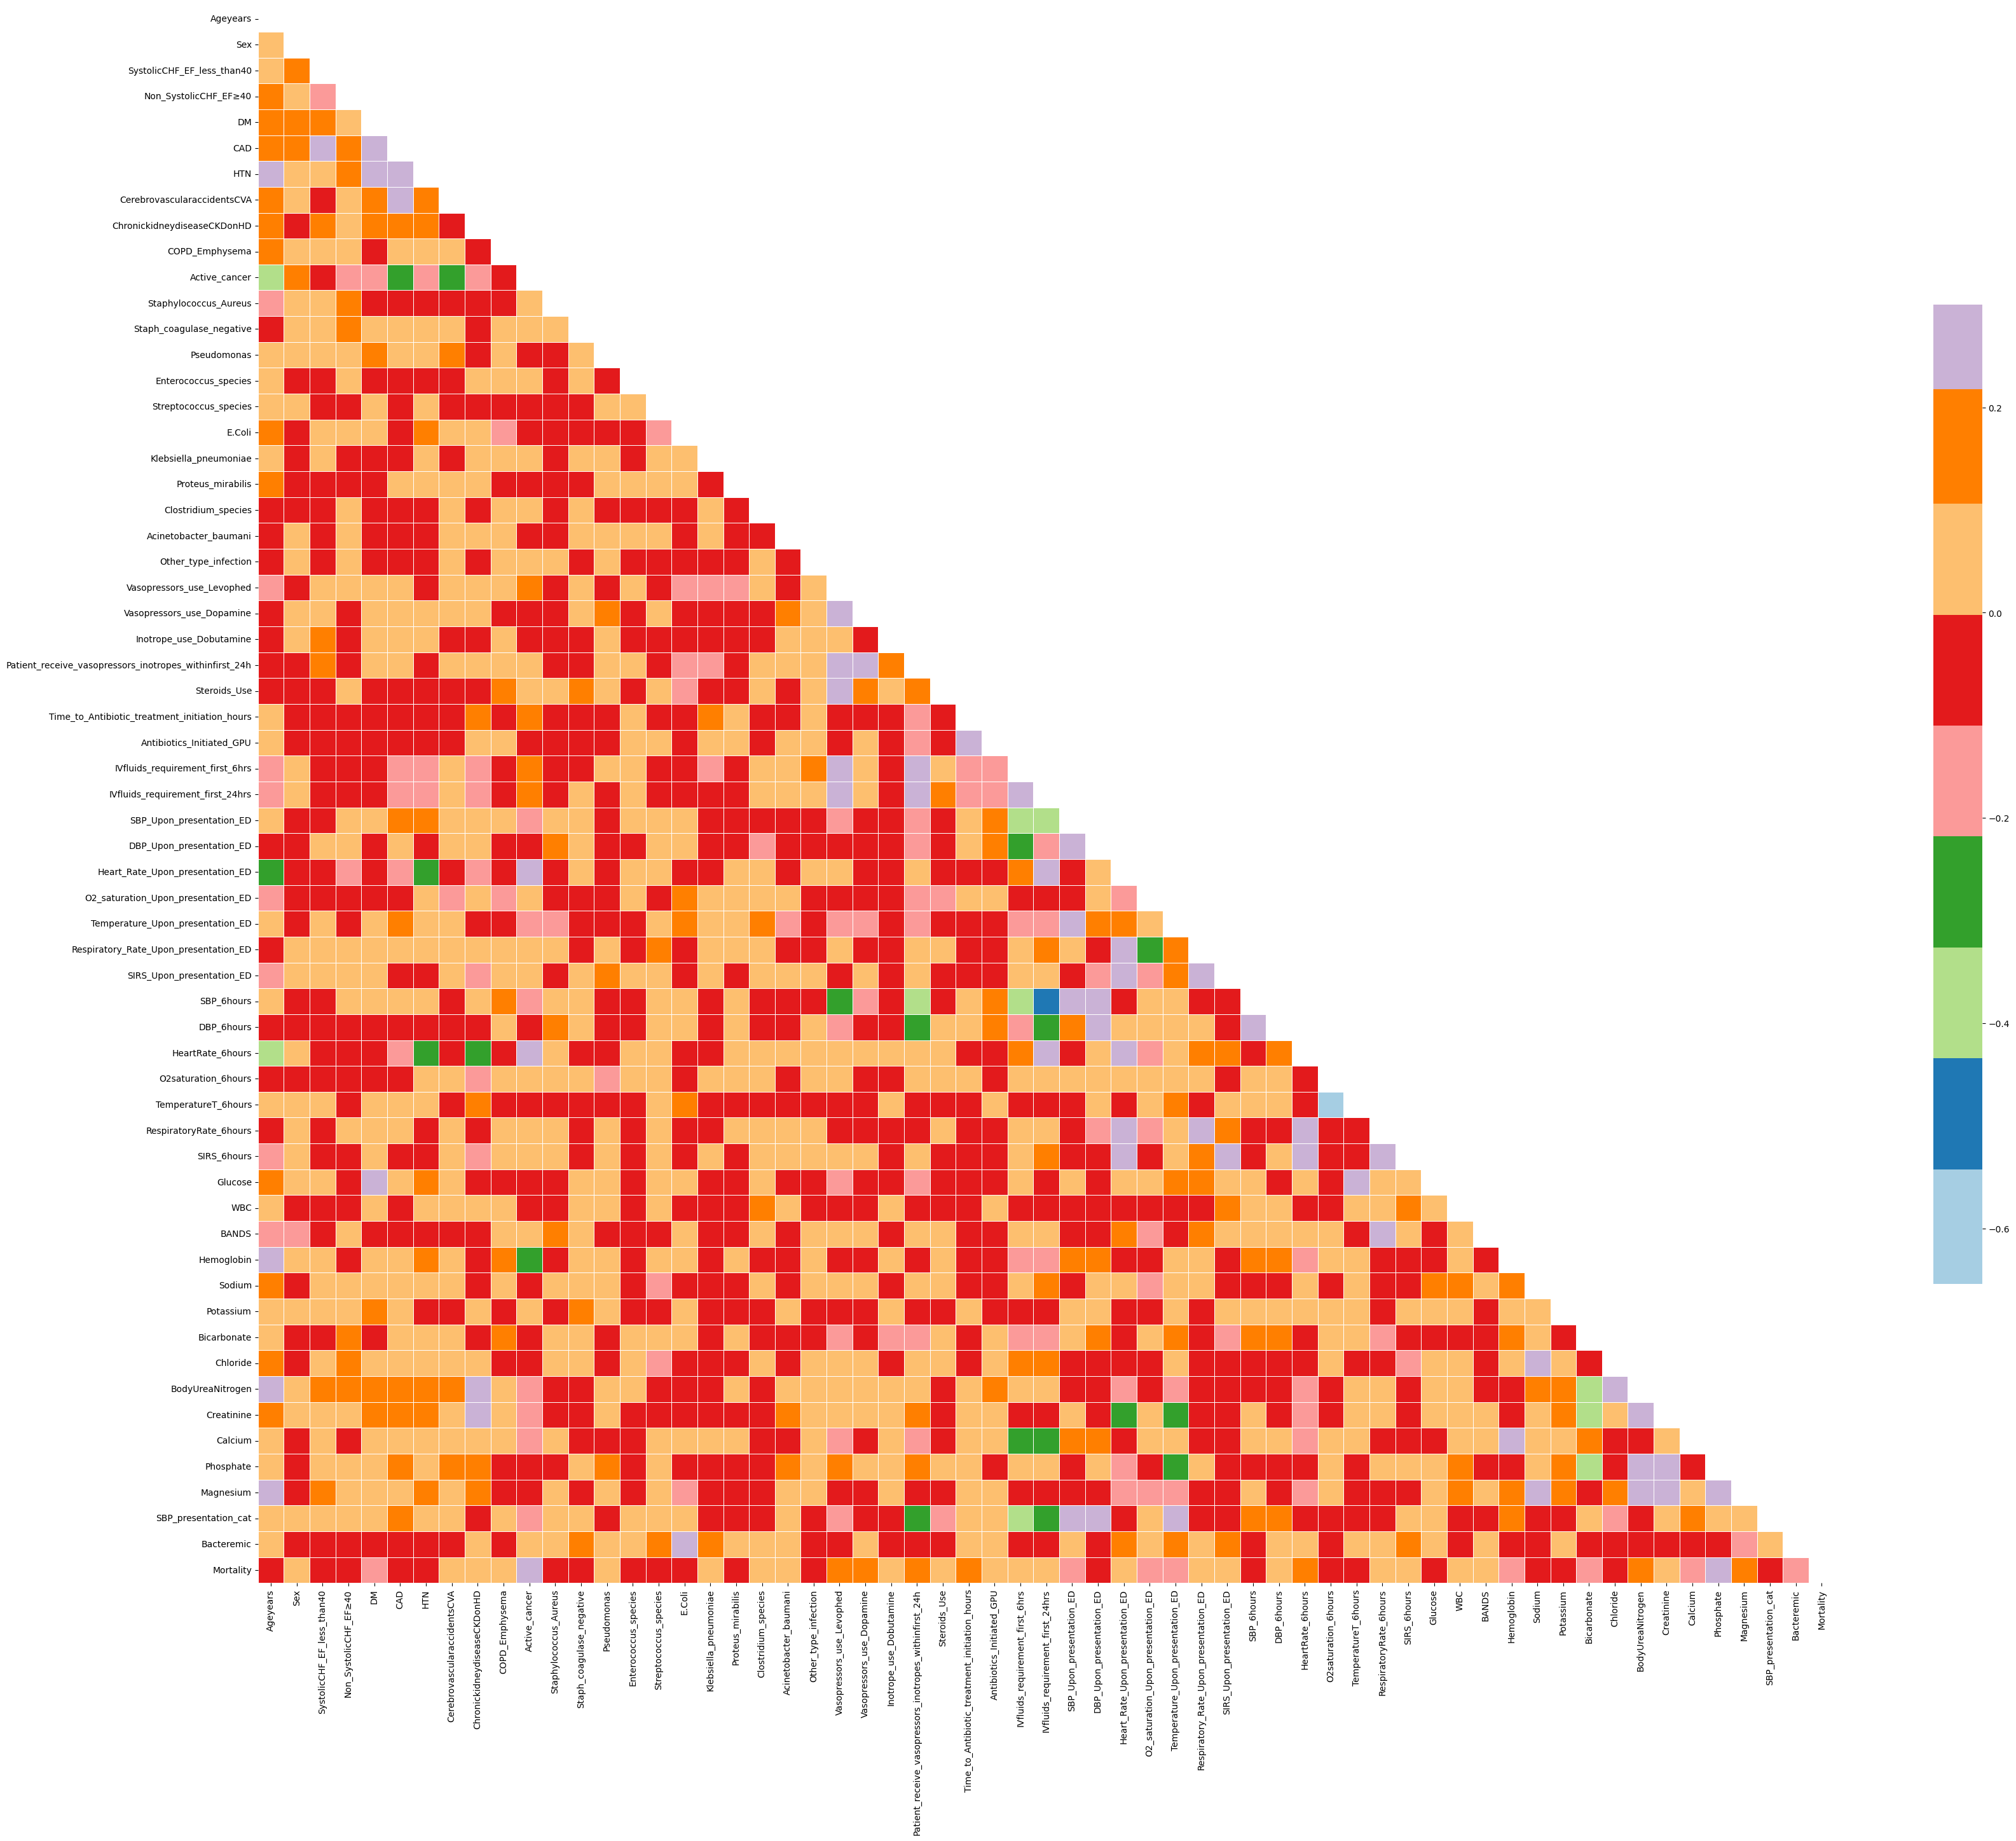

In [11]:
# correlation matrix to check if there is high correlation between the remaining features

corr_matrix(df_train_mod)

## Imputation

In [12]:
df_impute = df_train_mod.copy()
columns_impute = list(df_impute.columns)

In [13]:
# Now let's check the remaining proportion of missing values

null_values = df_impute.isnull().mean()*100
null_values = null_values.sort_values(ascending=False)
null_col = null_values[null_values >= 25].index.tolist()
print(columns_drop)

['gram_neg_bacilli_blood', 'gram_neg_bacilli_urine', 'gram_neg_bacilli_wound', 'streptococcus_other', 'klebsiella_other', 'gram_neg_bacilli_sputum', 'Active_Cancer_type3', 'clostridium_species_urine', 'clostridium_species_wound', 'clostridium_sputum', 'Other_medical_history', 'Cancer_Remission_type2', 'Cortisol_level', 'enterococcus_wound', 'enterococcus_sputum', 'Active_Cancer_type2', 'proteus_mirabilis_wound', 'streptococcus_wound', 'streptococcus_urine', 'Antibiotic4', 'Cancer_Remission_type1', 'BMT', 'Name_other_type_infection', 'Troponin_cat', 'CKMB', 'Antibiotic3', 'Antibiotic1', 'Steroid_type', 'Troponin', 'Antibiotic2', 'Appropriate_antibiotics', 'BilirubinTotal', 'Time_to_vasopressors_inotropes_withinfirst_24hours', 'Vasopressors_inotropes_Treatment_Duration_withinfirst_24hours', 'EF_non_EF_control', 'prevotella', 'Active_Cancer_type1_cat', 'gram_neg_bacilli', 'Streptococcus_species_name', 'Tumors_type', 'propionibacterium', 'Hospital_LOS_days_onlysurvived_multivariate', 'Loca

In [14]:
# dropping all the columns with null values more than 25%, SBP and DBP for redundancy, patient_id

df_impute = df_impute.drop(columns=null_col)
df_impute.columns

Index(['Ageyears', 'Sex', 'SystolicCHF_EF_less_than40',
       'Non_SystolicCHF_EF≥40', 'DM', 'CAD', 'HTN',
       'CerebrovascularaccidentsCVA', 'ChronickidneydiseaseCKDonHD',
       'COPD_Emphysema', 'Active_cancer', 'Staphylococcus_Aureus',
       'Staph_coagulase_negative', 'Pseudomonas', 'Enterococcus_species',
       'Streptococcus_species', 'E.Coli', 'Klebsiella_pneumoniae',
       'Proteus_mirabilis', 'Clostridium_species', 'Acinetobacter_baumani',
       'Other_type_infection', 'Vasopressors_use_Levophed',
       'Vasopressors_use_Dopamine', 'Inotrope_use_Dobutamine',
       'Patient_receive_vasopressors_inotropes_withinfirst_24h',
       'Steroids_Use', 'Time_to_Antibiotic_treatment_initiation_hours',
       'Antibiotics_Initiated_GPU', 'IVfluids_requirement_first_6hrs',
       'IVfluids_requirement_first_24hrs', 'SBP_Upon_presentation_ED',
       'DBP_Upon_presentation_ED', 'Heart_Rate_Upon_presentation_ED',
       'O2_saturation_Upon_presentation_ED',
       'Temperature_Up

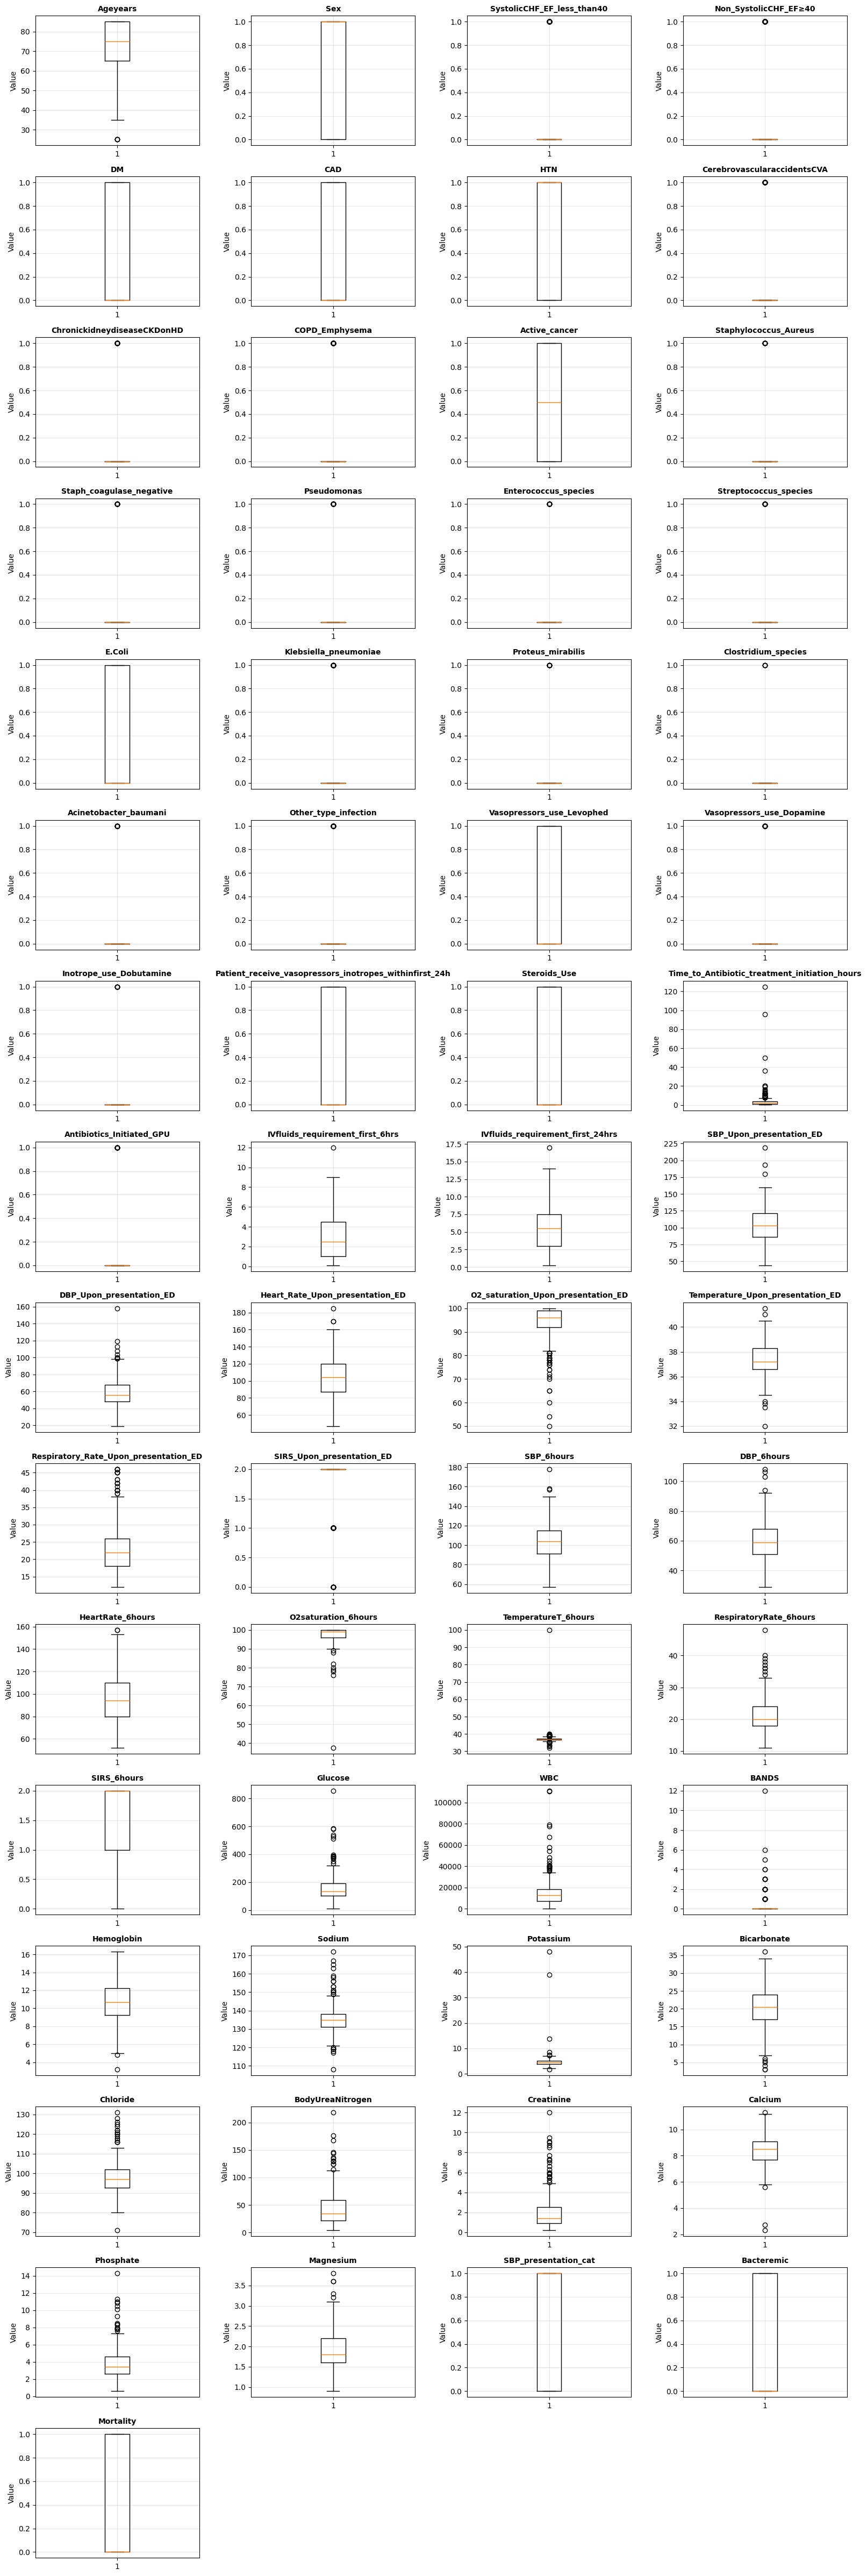

SUMMARY STATISTICS FOR NUMERIC FEATURES

Ageyears:
  Mean: 69.32, Std: 14.35
  Min: 25.00, Max: 85.00
  Q1: 65.00, Q3: 85.00, IQR: 20.00
  Outlier bounds: [35.00, 115.00]
  Number of outliers: 4 (1.2%)

Sex:
  Mean: 0.58, Std: 0.49
  Min: 0.00, Max: 1.00
  Q1: 0.00, Q3: 1.00, IQR: 1.00
  Outlier bounds: [-1.50, 2.50]
  Number of outliers: 0 (0.0%)

SystolicCHF_EF_less_than40:
  Mean: 0.17, Std: 0.37
  Min: 0.00, Max: 1.00
  Q1: 0.00, Q3: 0.00, IQR: 0.00
  Outlier bounds: [0.00, 0.00]
  Number of outliers: 59 (16.8%)

Non_SystolicCHF_EF≥40:
  Mean: 0.24, Std: 0.43
  Min: 0.00, Max: 1.00
  Q1: 0.00, Q3: 0.00, IQR: 0.00
  Outlier bounds: [0.00, 0.00]
  Number of outliers: 85 (24.1%)

DM:
  Mean: 0.37, Std: 0.48
  Min: 0.00, Max: 1.00
  Q1: 0.00, Q3: 1.00, IQR: 1.00
  Outlier bounds: [-1.50, 2.50]
  Number of outliers: 0 (0.0%)

CAD:
  Mean: 0.34, Std: 0.47
  Min: 0.00, Max: 1.00
  Q1: 0.00, Q3: 1.00, IQR: 1.00
  Outlier bounds: [-1.50, 2.50]
  Number of outliers: 0 (0.0%)

HTN:
  Mean: 0.

In [15]:
# Visualize distribution of all numeric features in df_impute to identify outliers
numeric_features = df_impute.select_dtypes(include=[np.number]).columns.tolist()

# Create subplots for all numeric features
n_features = len(numeric_features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for idx, feature in enumerate(numeric_features):
    ax = axes[idx]
    
    # Box plot to show outliers
    ax.boxplot(df_impute[feature].dropna(), vert=True)
    ax.set_title(f'{feature}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# Print summary statistics for each numeric feature
print("=" * 80)
print("SUMMARY STATISTICS FOR NUMERIC FEATURES")
print("=" * 80)

for feature in numeric_features:
    data = df_impute[feature].dropna()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    
    print(f"\n{feature}:")
    print(f"  Mean: {data.mean():.2f}, Std: {data.std():.2f}")
    print(f"  Min: {data.min():.2f}, Max: {data.max():.2f}")
    print(f"  Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")
    print(f"  Outlier bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Number of outliers: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")

In [16]:
# Ubah fitur lab kontinu menjadi kategori
lab_cols = ["WBC", "Creatinine", "Glucose", "BANDS","BodyUreaNitrogen", "Hemoglobin", "Bicarbonate", "Ageyears","Heart_Rate_Upon_presentation_ED","HeartRate_6hours","Time_to_Antibiotic_treatment_initiation_hours"]

def bin_lab_series(s):
    if s.isna().all():
        return s

    match s.name:
        case "WBC":
            bins = [-np.inf, 4000, 11000, np.inf]
            labels = ["Low", "Normal", "High"]
        case "Creatinine":
            bins = [-np.inf, 1.2, 2.4, np.inf]
            labels = ["Normal", "Mild", "Severe"]
        case "Glucose":
            bins = [-np.inf, 70, 140, np.inf]
            labels = ["Low", "Normal", "High"]
        case "BANDS":
            bins = [-np.inf, 10.0, np.inf]
            labels = ["Normal", "High"]
        case "BodyUreaNitrogen":
            bins = [0, 20.0, 50.0, np.inf]
            labels = ["Normal", "Moderate", "Severe"]
        case "Hemoglobin":
            bins = [0, 10.0, 13.0, np.inf]
            labels = ["Severe_Anemia", "Mild_Anemia", "Normal"]
        case "Bicarbonate":
            bins = [0, 22.0, 26.0, np.inf]
            labels = ["Low", "Normal", "High"]

        case "Heart_Rate_Upon_presentation_ED":        
            bins = [0, 60, 100, np.inf]
            labels = ["Low", "Normal", "High"]
        case "HeartRate_6hours":        
            bins = [0, 60, 100, np.inf]
            labels = ["Low", "Normal", "High"]
    
        case "Ageyears":
            bins = [0.0, 40.0, 60.0, np.inf]
            labels = ["Young", "Middle_Aged", "Elderly"]
        case "Time_to_Antibiotic_treatment_initiation_hours":
            bins = [-np.inf, 1.0, 3.0, np.inf]
            labels = ["Immediate_Within_1h", "Delayed_1_3h", "Late_Over_3h"]
        case _:
            return s

    return pd.cut(s, bins=bins, labels=labels, include_lowest=True)


for col in lab_cols:
    if col in df_impute.columns:
        df_impute[col] = bin_lab_series(df_impute[col])

df_impute[lab_cols].head()

,WBC,Creatinine,Glucose,BANDS,BodyUreaNitrogen,Hemoglobin,Bicarbonate,Ageyears,Heart_Rate_Upon_presentation_ED,HeartRate_6hours,Time_to_Antibiotic_treatment_initiation_hours
0,High,Mild,Normal,Normal,Moderate,Mild_Anemia,Low,Elderly,High,High,Immediate_Within_1h
1,High,Mild,High,Normal,Moderate,Mild_Anemia,Normal,Elderly,Normal,Normal,Delayed_1_3h
2,Normal,Severe,Normal,Normal,Severe,Severe_Anemia,Low,Middle_Aged,Normal,Normal,Delayed_1_3h
3,High,Normal,Normal,Normal,Moderate,Mild_Anemia,High,Elderly,Normal,Low,Late_Over_3h
4,High,Mild,Normal,Normal,Moderate,Mild_Anemia,Low,Elderly,Normal,Low,Delayed_1_3h


In [17]:
df_impute.head()

,Ageyears,Sex,SystolicCHF_EF_less_than40,Non_SystolicCHF_EF≥40,DM,CAD,HTN,CerebrovascularaccidentsCVA,ChronickidneydiseaseCKDonHD,COPD_Emphysema,...,Bicarbonate,Chloride,BodyUreaNitrogen,Creatinine,Calcium,Phosphate,Magnesium,SBP_presentation_cat,Bacteremic,Mortality
0,Elderly,1,1,0,0,1,1,0,0,0,...,Low,103,Moderate,Mild,8.0,2.8,2.3,1,0,0
1,Elderly,1,0,1,1,1,1,0,0,0,...,Normal,89,Moderate,Mild,9.2,2.2,1.4,1,1,0
2,Middle_Aged,0,0,0,1,1,0,0,1,0,...,Low,99,Severe,Severe,9.4,11.3,2.7,0,0,0
3,Elderly,1,0,0,1,0,1,0,0,1,...,High,89,Moderate,Normal,9.4,2.2,1.6,1,0,0
4,Elderly,1,0,1,0,0,1,0,0,0,...,Low,95,Moderate,Mild,8.3,3.5,1.9,0,1,0


In [18]:
df_impute = df_impute.dropna()

In [19]:
null_values = df_impute.isnull().mean()*100
null_values

Ageyears                      0.0
Sex                           0.0
SystolicCHF_EF_less_than40    0.0
Non_SystolicCHF_EF≥40         0.0
DM                            0.0
                             ... 
Phosphate                     0.0
Magnesium                     0.0
SBP_presentation_cat          0.0
Bacteremic                    0.0
Mortality                     0.0
Length: 61, dtype: float64

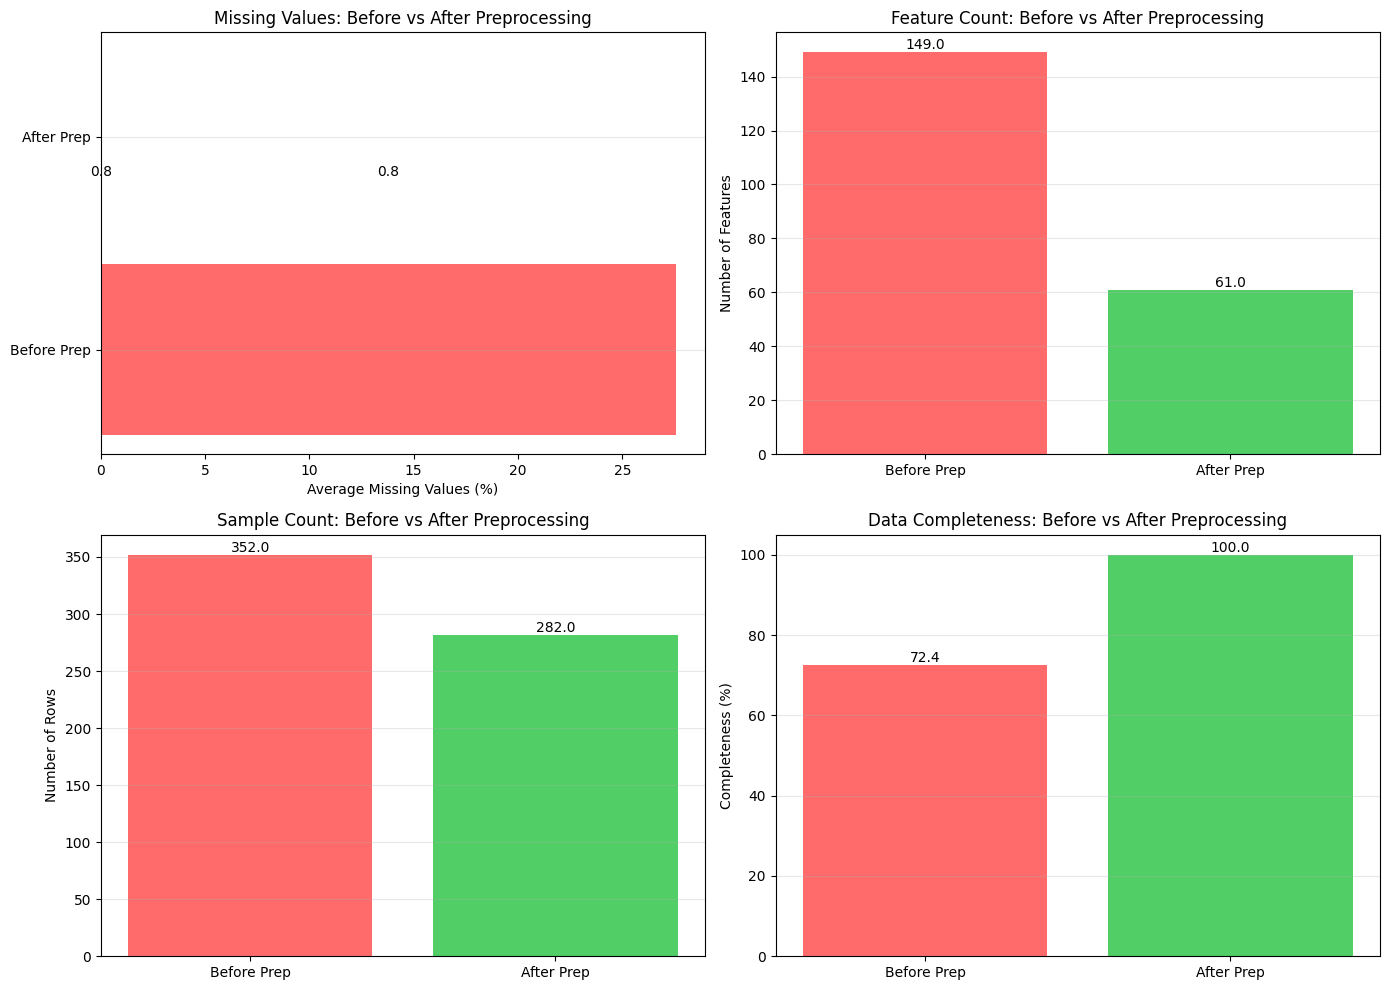


=== DATA PREPROCESSING SUMMARY ===
Features removed: 88
Rows removed: 70
Data completeness improvement: 27.58%


In [20]:
# Comparison visualization: Before and After Data Preprocessing

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Missing Values Comparison
null_before = df.isnull().mean() * 100
null_after = df_impute.isnull().mean() * 100

axes[0, 0].barh(['Before Prep', 'After Prep'], 
                [null_before.mean(), null_after.mean()], 
                color=['#ff6b6b', '#51cf66'])
axes[0, 0].set_xlabel('Average Missing Values (%)')
axes[0, 0].set_title('Missing Values: Before vs After Preprocessing')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Feature Count Comparison
axes[0, 1].bar(['Before Prep', 'After Prep'], 
              [df.shape[1], df_impute.shape[1]], 
              color=['#ff6b6b', '#51cf66'])
axes[0, 1].set_ylabel('Number of Features')
axes[0, 1].set_title('Feature Count: Before vs After Preprocessing')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Row Count Comparison
axes[1, 0].bar(['Before Prep', 'After Prep'], 
              [df.shape[0], df_impute.shape[0]], 
              color=['#ff6b6b', '#51cf66'])
axes[1, 0].set_ylabel('Number of Rows')
axes[1, 0].set_title('Sample Count: Before vs After Preprocessing')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Data Completeness
completeness_before = (1 - null_before.mean()/100) * 100
completeness_after = (1 - null_after.mean()/100) * 100

axes[1, 1].bar(['Before Prep', 'After Prep'], 
              [completeness_before, completeness_after], 
              color=['#ff6b6b', '#51cf66'])
axes[1, 1].set_ylabel('Completeness (%)')
axes[1, 1].set_title('Data Completeness: Before vs After Preprocessing')
axes[1, 1].set_ylim([0, 105])
axes[1, 1].grid(axis='y', alpha=0.3)

for ax in axes.flat:
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2., height,
                f'{height:.1f}', ha="center", va="bottom")

plt.tight_layout()
plt.show()

print("\n=== DATA PREPROCESSING SUMMARY ===")
print(f"Features removed: {df.shape[1] - df_impute.shape[1]}")
print(f"Rows removed: {df.shape[0] - df_impute.shape[0]}")
print(f"Data completeness improvement: {completeness_after - completeness_before:.2f}%")

# Model Building

In [21]:
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, valid_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring='f1',  
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    valid_mean = valid_scores.mean(axis=1)

    plt.figure(figsize=(7, 5))
    plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
    plt.plot(train_sizes, valid_mean, marker='o', label='Validation Score')

    plt.title(title)
    plt.xlabel("Jumlah Data Latih")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [22]:
# this fucntion calculates different evaluation parameters of a model

def evaluate_model(y_true,y_pred):
  accuracy = accuracy_score(y_true, y_pred)
  print("Accuracy:", accuracy)
  precision = precision_score(y_true, y_pred)
  print("Precision:", precision)
  recall = recall_score(y_true, y_pred)
  print("Recall:", recall)
  f1 = f1_score(y_true, y_pred)
  print("F1 Score:", f1)
  auc = roc_auc_score(y_true, y_pred)
  print("AUC-ROC:", auc)
  mae = mean_absolute_error(y_true, y_pred)
  print("Mean Absolute Error:", mae)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  print("Root Mean Squared Error:", rmse)
  cm = confusion_matrix(y_true, y_pred)
  sns.heatmap(cm, annot=True, fmt='d')
  plt.show()

In [23]:
# checking the distribution of data points between the two classes

death_class = df_impute[df_impute['Mortality'] == 0]
non_death_class = df_impute[df_impute['Mortality'] == 1]
print('number of patient died in 28 days is {}'.format(len(death_class)))
print('while number of patient not die in 28 days is {}'.format(len(non_death_class)))

# Print total fitur
total_fitur = df_impute.drop(columns=['Mortality']).shape[1]
print(f'total fitur: {total_fitur}')

number of patient died in 28 days is 180
while number of patient not die in 28 days is 102
total fitur: 60


## XGBoost

In [24]:
cols_drop = [
    'StudyID', 'Study_type', 'Site_of_infection', 'Code',
    'Cancer_in_remission', 'Diagnosis', 'DCHome',
    "Antibiotics_Initiated_ED", "Antibiotics_Initiated_ICU",
    'ICU_LOS_days', 'GPU_LOS_days', 'Hospital_LOS_days',
    'ICU_LOS_hours', 'GPU_LOS_hours', 'Hospital_LOS_hours',
    'ED_Length_of_Stay_LOS_hours', 'Admission_to_hospital',
    'Antibiotics_Used', 'Undergone_chemotherapy', 'Undergone_radiation_therapy',
    'Undergone_surgical_therapy', 'ICU_GPU_admission', 'ICU_Admission',
    'GPU_Admission', "ED_Disposition"
]

In [25]:
def parse_ageyears(value):
        if isinstance(value, str) and value.strip() == ">90":
            return 90.0
        if pd.isna(value):
            return np.nan
        if isinstance(value, (int, float, np.integer, np.floating)):
            return float(value)
        text = str(value).strip()
        if "-" in text:
            low, high = text.split("-", 1)
            return (float(low) + float(high)) / 2
        return pd.to_numeric(text, errors="coerce")

In [26]:
def clean_data_train(x):
    x = x.copy()

    # Drop high null
    null_ratio = x.isnull().mean()
    drop_high_null = null_ratio[null_ratio >= 0.25].index.tolist()
    x = x.drop(columns=drop_high_null, errors="ignore")

    # Correlation filtering
    numeric_cols = x.select_dtypes(include=[np.number]).columns.tolist()
    if "Active_cancer" in numeric_cols:
        numeric_cols.remove(
            "Active_cancer"
        )   
    if len(numeric_cols) > 1:
        corr = x[numeric_cols].corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        cols_corr_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
        x = x.drop(columns=cols_corr_drop, errors="ignore")
    else:
        cols_corr_drop = []
    
    for col in lab_cols:
        if col in x.columns:
            x[col] = bin_lab_series(x[col])

    metadata = {
        "drop_high_null": drop_high_null,
        "cols_corr_drop": cols_corr_drop,
        "final_columns": x.columns.tolist(),
    }

    return x, metadata

In [27]:
def clean_data_test(x, metadata):
    x = x.copy()

    x = x.drop(columns=metadata["drop_high_null"], errors="ignore")
    x = x.drop(columns=metadata["cols_corr_drop"], errors="ignore")
    
    for col in lab_cols:
        if col in x.columns:
            x[col] = bin_lab_series(x[col])

    x = x.reindex(columns=metadata["final_columns"], fill_value=0)
    
    return x

In [28]:
# train test split for the imputed output

df_prep = df.copy()
df_prep['Mortality'] = df_prep.apply(create_mortality_label, axis=1)
df_prep = df_prep.drop(
    columns=[
        "Mortality_28days",
        "Mortality_72hours",
        "Mortality_60days",
        "Expired_at_hospital_during_this_admission"
    ]
)
    
if "Ageyears" in df_prep.columns:
    df_prep["Ageyears"] = (
        df_prep["Ageyears"].apply(parse_ageyears).astype(float)
    )

null_values = df_prep.isnull().mean()*100
null_values = null_values.sort_values(ascending=False)
null_col = null_values[null_values >= 25].index.tolist()

df_prep = df_prep.drop(columns=null_col)

df_prep = df_prep.drop(
    columns=[c for c in cols_drop if c in df_prep.columns], errors="ignore"
)

df_prep = df_prep.dropna()

X = df_prep.drop(columns=["Mortality"])
y = df_prep["Mortality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

X_train, metadata = clean_data_train(X_train)
X_test = clean_data_test(X_test, metadata)


print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (224, 61), y_train shape: (224,)
X_test shape: (75, 61), y_test shape: (75,)


In [29]:
X_train

,Ageyears,Sex,SystolicCHF_EF_less_than40,Non_SystolicCHF_EF≥40,DM,CAD,HTN,CerebrovascularaccidentsCVA,ChronickidneydiseaseCKDonHD,COPD_Emphysema,...,Potassium,Bicarbonate,Chloride,BodyUreaNitrogen,Creatinine,Calcium,Phosphate,Magnesium,SBP_presentation_cat,Bacteremic
201,Elderly,1,0,0,0,0,0,0,0,0,...,4.3,Low,107,Moderate,Mild,6.9,1.4,1.5,0,0
123,Young,0,0,0,0,0,0,0,0,0,...,4.7,Low,103,Normal,Mild,8.4,2.2,1.7,1,0
115,Elderly,1,0,0,0,1,1,0,1,0,...,5.2,Low,113,Severe,Severe,9.7,3.1,1.7,1,0
247,Elderly,1,0,0,0,0,1,0,0,1,...,3.8,High,105,Moderate,Mild,7.3,3.0,1.7,0,0
323,Elderly,1,0,1,0,0,0,0,0,1,...,5.8,Low,100,Moderate,Mild,7.6,5.7,2.5,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,Elderly,0,0,0,0,0,1,0,0,0,...,4.6,Low,83,Moderate,Mild,10.1,4.5,1.8,0,1
282,Elderly,0,0,0,1,0,1,0,0,0,...,3.1,High,89,Moderate,Normal,8.3,3.5,1.7,1,1
93,Elderly,0,0,1,0,0,0,0,0,0,...,6.0,High,103,Severe,Normal,9.3,4.4,2.3,1,0
278,Elderly,1,0,0,1,0,1,0,0,0,...,3.6,Low,103,Moderate,Normal,8.5,0.9,1.6,1,1


CLASS BALANCE ANALYSIS

Training Set:
  Mortality = 0 (No): 142 (63.4%)
  Mortality = 1 (Yes): 82 (36.6%)
  Total: 224

Test Set:
  Mortality = 0 (No): 48 (64.0%)
  Mortality = 1 (Yes): 27 (36.0%)
  Total: 75


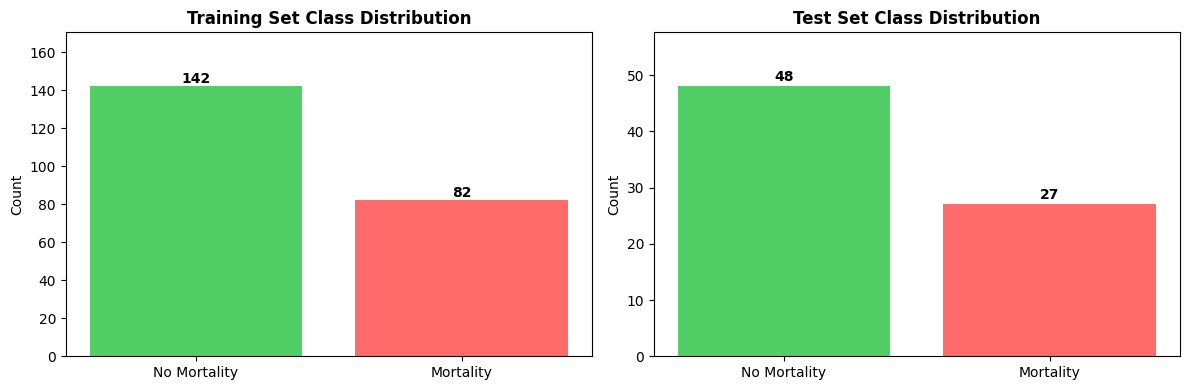


Class Ratio (No:Yes):
  Training: 1.73:1
  Test: 1.78:1


In [30]:
# Check class balance in training and test sets

train_mortality_0 = (y_train == 0).sum()
train_mortality_1 = (y_train == 1).sum()

test_mortality_0 = (y_test == 0).sum()
test_mortality_1 = (y_test == 1).sum()

print("=" * 50)
print("CLASS BALANCE ANALYSIS")
print("=" * 50)

print(f"\nTraining Set:")
print(f"  Mortality = 0 (No): {train_mortality_0} ({train_mortality_0/len(y_train)*100:.1f}%)")
print(f"  Mortality = 1 (Yes): {train_mortality_1} ({train_mortality_1/len(y_train)*100:.1f}%)")
print(f"  Total: {len(y_train)}")

print(f"\nTest Set:")
print(f"  Mortality = 0 (No): {test_mortality_0} ({test_mortality_0/len(y_test)*100:.1f}%)")
print(f"  Mortality = 1 (Yes): {test_mortality_1} ({test_mortality_1/len(y_test)*100:.1f}%)")
print(f"  Total: {len(y_test)}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Train set
axes[0].bar(['No Mortality', 'Mortality'], [train_mortality_0, train_mortality_1], 
            color=['#51cf66', '#ff6b6b'])
axes[0].set_title('Training Set Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(train_mortality_0, train_mortality_1) * 1.2)
for i, v in enumerate([train_mortality_0, train_mortality_1]):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Test set
axes[1].bar(['No Mortality', 'Mortality'], [test_mortality_0, test_mortality_1], 
            color=['#51cf66', '#ff6b6b'])
axes[1].set_title('Test Set Class Distribution', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, max(test_mortality_0, test_mortality_1) * 1.2)
for i, v in enumerate([test_mortality_0, test_mortality_1]):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Class ratio
print(f"\nClass Ratio (No:Yes):")
print(f"  Training: {train_mortality_0/train_mortality_1:.2f}:1")
print(f"  Test: {test_mortality_0/test_mortality_1:.2f}:1")

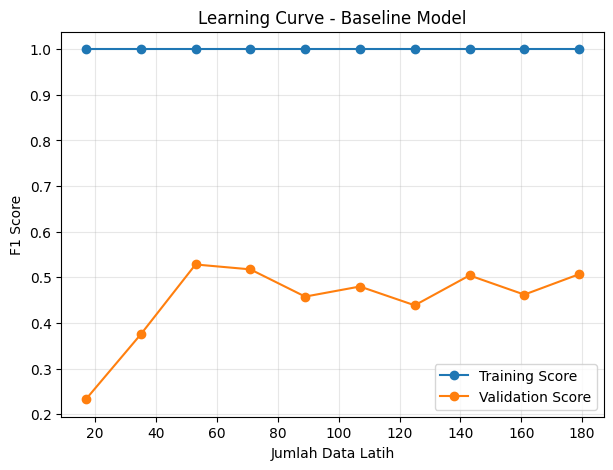

Accuracy: 0.6533333333333333
Precision: 0.5263157894736842
Recall: 0.37037037037037035
F1 Score: 0.43478260869565216
AUC-ROC: 0.5914351851851851
Mean Absolute Error: 0.3466666666666667
Root Mean Squared Error: 0.5887840577551898


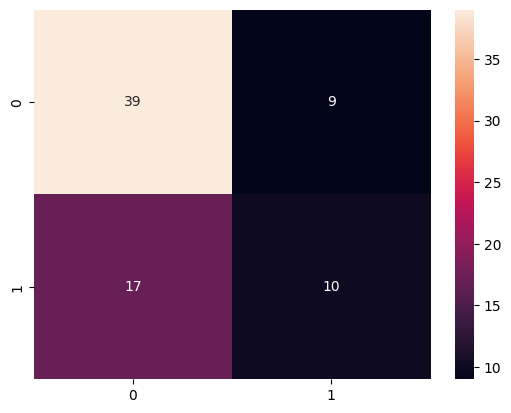

In [31]:
# Baseline model without feature selection 
baseline_model = XGBClassifier(
    objective='binary:logistic', 
    random_state=42, 
    enable_categorical=True
)

plot_learning_curve(
    baseline_model,
    X_train,
    y_train,
    title="Learning Curve - Baseline Model"
)

baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)
evaluate_model(y_test, y_pred_baseline)

### Feature Selection

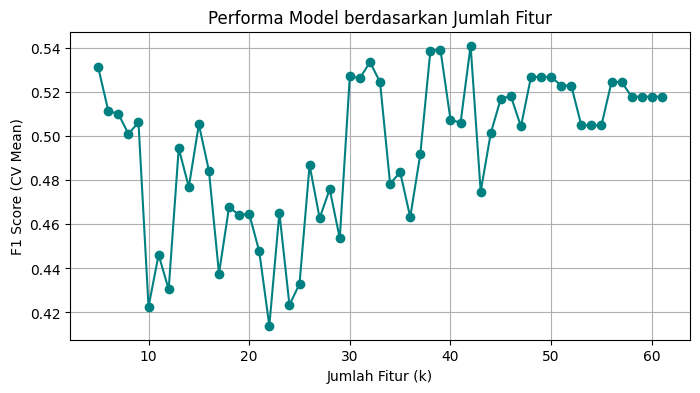

=== HASIL OPTIMAL (NO LEAKAGE) ===
Best k (jumlah fitur): 42
Best CV F1 Score: 0.5411

=== TEST PERFORMANCE ===
Accuracy: 0.6400
Precision: 0.5000
F1 Score: 0.3721

Selected Features:
['SIRS_Upon_presentation_ED', 'Phosphate', 'WBC', 'SystolicCHF_EF_less_than40', 'Creatinine', 'CerebrovascularaccidentsCVA', 'IVfluids_requirement_first_24hrs', 'Steroids_Use', 'Heart_Rate_Upon_presentation_ED', 'Magnesium', 'Hemoglobin', 'Non_SystolicCHF_EF≥40', 'Patient_receive_vasopressors_inotropes_withinfirst_24h', 'HeartRate_6hours', 'Pseudomonas', 'SBP_Upon_presentation_ED', 'Potassium', 'Calcium', 'Chloride', 'TemperatureT_6hours', 'COPD_Emphysema', 'BodyUreaNitrogen', 'Respiratory_Rate_Upon_presentation_ED', 'Active_cancer', 'O2_saturation_Upon_presentation_ED', 'Bicarbonate', 'Temperature_Upon_presentation_ED', 'MAP_6hours', 'Glucose', 'DM', 'Time_to_Antibiotic_treatment_initiation_hours', 'Ageyears', 'O2saturation_6hours', 'IVfluids_requirement_first_6hrs', 'HTN', 'CAD', 'RespiratoryRate_6hours

In [32]:
from sklearn.metrics import accuracy_score, precision_score, f1_score
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# ======================
# 1. Feature ranking (ONLY TRAIN DATA)
# ======================
xgb_temp = XGBClassifier(random_state=42, enable_categorical=True)
xgb_temp.fit(X_train, y_train)

importances = xgb_temp.feature_importances_
feature_importance_df = pd.DataFrame({
    'Fitur': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# ======================
# 2. Evaluasi jumlah fitur (ONLY TRAIN DATA via CV)
# ======================
k_list = range(5, len(X_train.columns)+1)

acc_scores = []
prec_scores = []
f1_scores = []

best_f1 = 0
best_k = 0
best_features = None

for k in k_list:
    selected = feature_importance_df.head(k)['Fitur']
    X_train_k = X_train[selected]

    model = XGBClassifier(random_state=42, enable_categorical=True)

    acc = cross_val_score(model, X_train_k, y_train, cv=5, scoring='accuracy').mean()
    prec = cross_val_score(model, X_train_k, y_train, cv=5, scoring='precision').mean()
    f1 = cross_val_score(model, X_train_k, y_train, cv=5, scoring='f1').mean()

    acc_scores.append(acc)
    prec_scores.append(prec)
    f1_scores.append(f1)

    if f1 > best_f1:
        best_f1 = f1
        best_k = k
        best_features = selected
    
plt.figure(figsize=(8, 4))
plt.plot(k_list, f1_scores, marker='o', linestyle='-', color='teal')
plt.title("Performa Model berdasarkan Jumlah Fitur")
plt.xlabel("Jumlah Fitur (k)")
plt.ylabel("F1 Score (CV Mean)")
plt.grid(True)
plt.show()

# ======================
# 3. Final model (TRAIN → TEST)
# ======================
X_train_final = X_train[best_features]
X_test_final = X_test[best_features]

final_model = XGBClassifier(random_state=42, enable_categorical=True)
final_model.fit(X_train_final, y_train)

y_pred = final_model.predict(X_test_final)

# ======================
# 4. Final evaluation (REAL PERFORMANCE)
# ======================
print("=== HASIL OPTIMAL (NO LEAKAGE) ===")
print(f"Best k (jumlah fitur): {best_k}")
print(f"Best CV F1 Score: {best_f1:.4f}")

print("\n=== TEST PERFORMANCE ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

print(f"\nSelected Features:\n{list(best_features)}")

C:\Users\gamin\AppData\Local\Temp\ipykernel_9792\933144554.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="Importance", y="Fitur", palette="viridis")


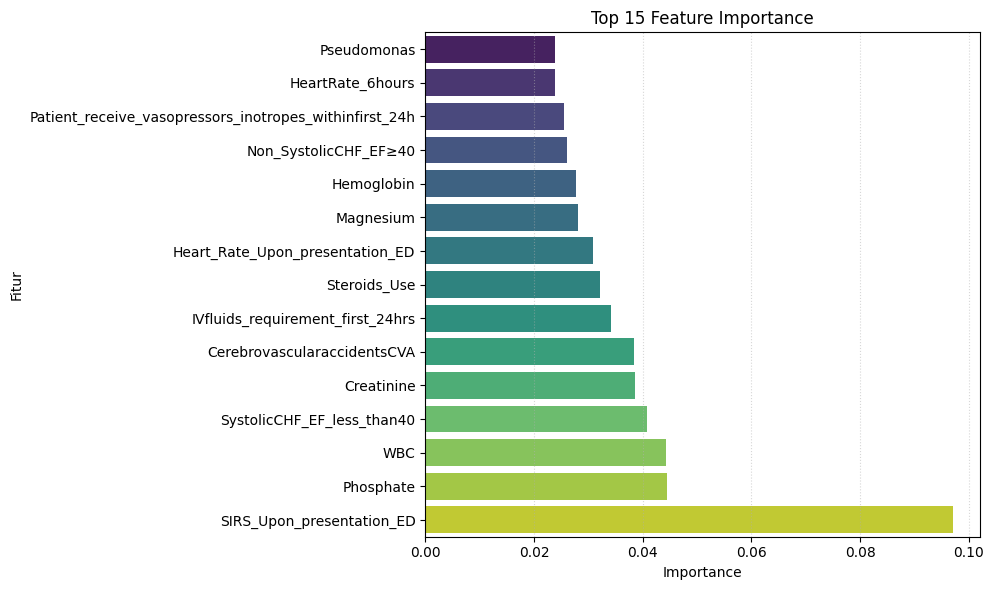

In [33]:
# Grafik feature importance

if "feature_importance_df" not in globals():
    feature_importance_df = pd.DataFrame({
        "Fitur": X_train.columns,
        "Importance": xgb_temp.feature_importances_
    }).sort_values(by="Importance", ascending=False)

top_n = 15
plot_df = feature_importance_df.head(top_n).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="Importance", y="Fitur", palette="viridis")
plt.title(f"Top {top_n} Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Fitur")
plt.grid(axis="x", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

In [34]:
X_train_slim = X_train[best_features]
X_test_slim = X_test[best_features]

Accuracy: 0.64
Precision: 0.5
Recall: 0.2962962962962963
F1 Score: 0.37209302325581395
AUC-ROC: 0.5648148148148149
Mean Absolute Error: 0.36
Root Mean Squared Error: 0.6


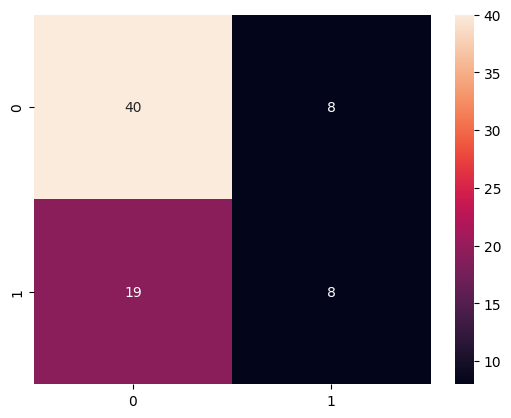

In [35]:
# XGBoost model score after feature selection with top 15 features

model_slim = XGBClassifier(objective='binary:logistic', random_state=42, enable_categorical=True)
model_slim.fit(X_train_slim, y_train)

y_pred_slim = model_slim.predict(X_test_slim)

evaluate_model(y_test, y_pred_slim)

### Param Grid Variables

In [36]:
param_grid = {
    'min_child_weight': [5, 7],
    'max_depth': [2],
    'learning_rate': [0.01, 0.05],
    'gamma': [2 ,5],
    'scale_pos_weight': [1, 1.5, 2],
    'subsample': [0.5, 1.0],
    'colsample_bytree': [0.5, 1.0],
}


=== GRID SEARCH UNTUK ACCURACY ===
Fitting 5 folds for each of 96 candidates, totalling 480 fits


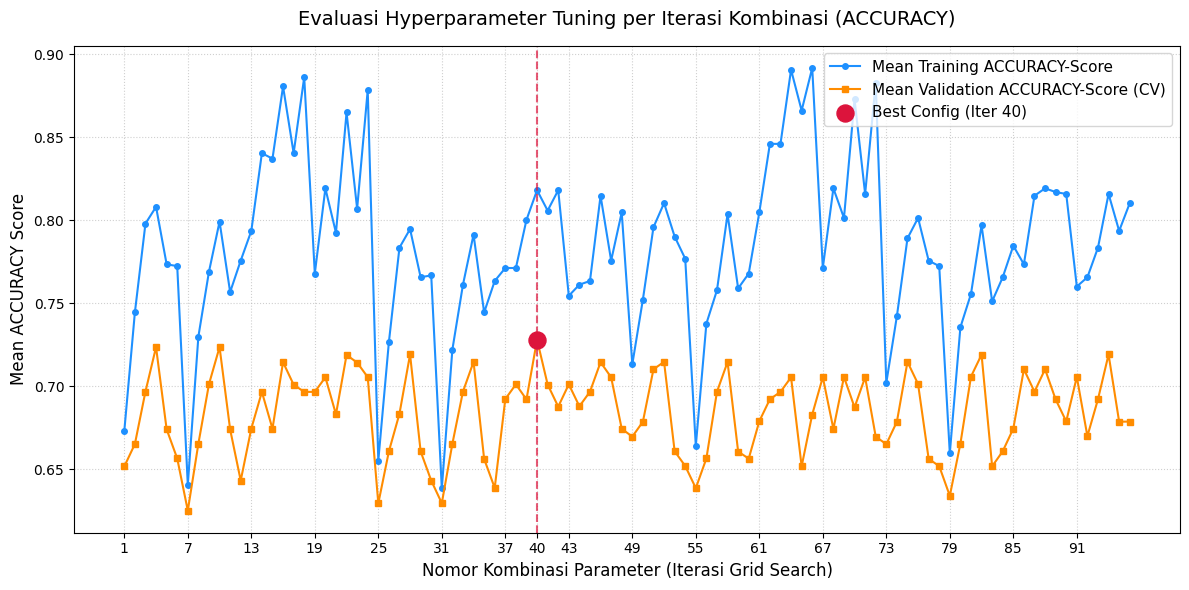


=== GRID SEARCH UNTUK PRECISION ===
Fitting 5 folds for each of 96 candidates, totalling 480 fits


c:\Users\gamin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gamin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gamin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

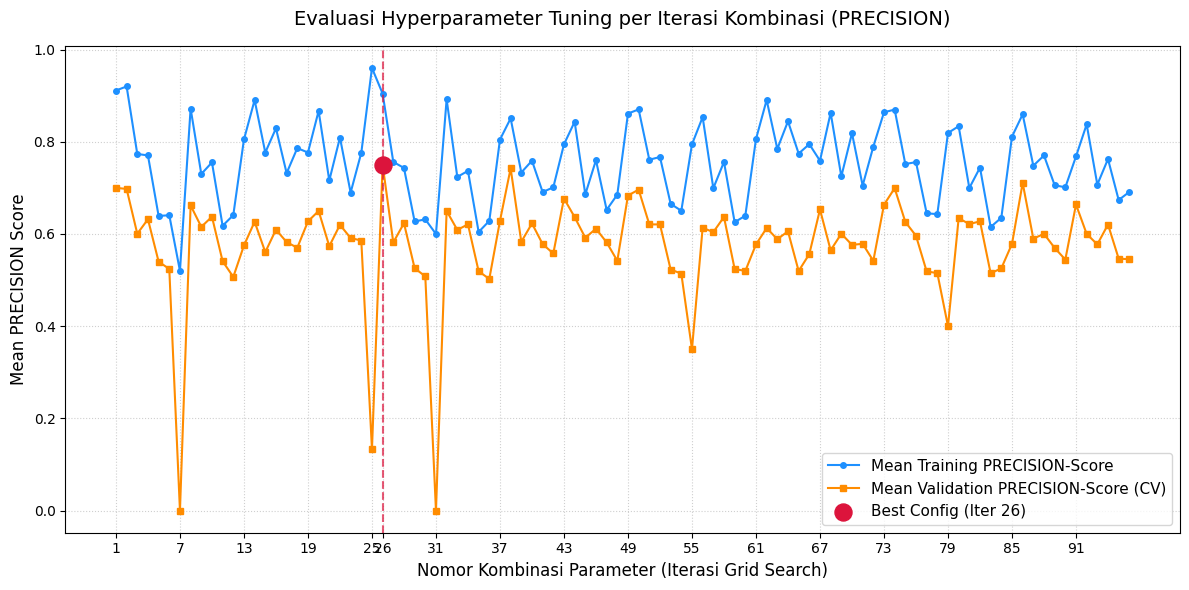


=== GRID SEARCH UNTUK F1 ===
Fitting 5 folds for each of 96 candidates, totalling 480 fits


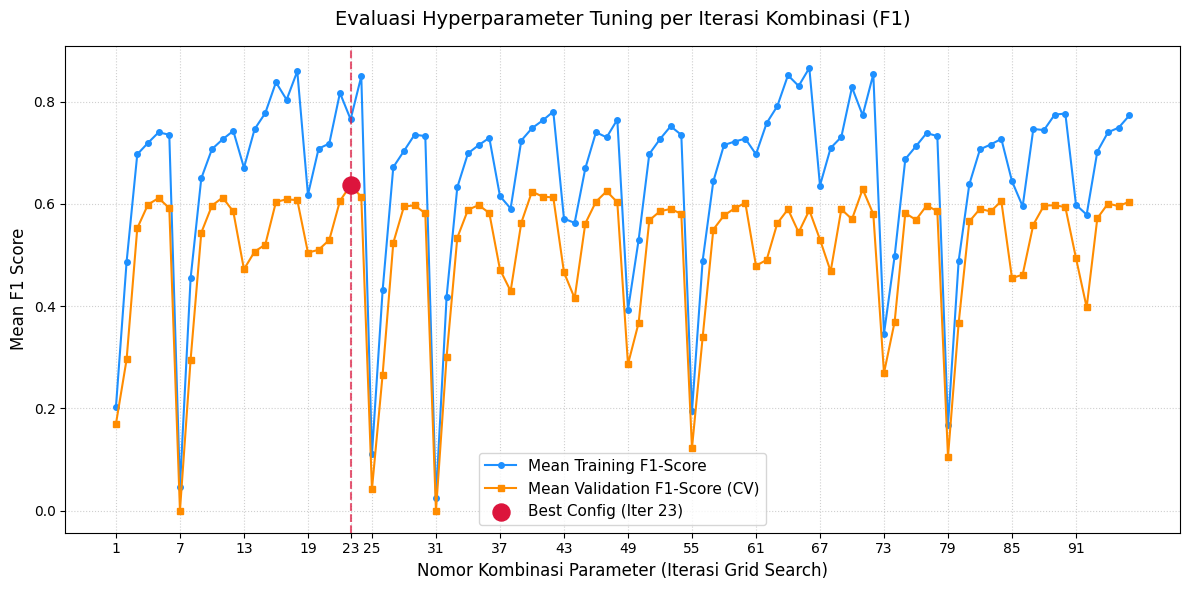


=== RINGKASAN HASIL ===
Accuracy Best: 0.727979797979798
Params: {'colsample_bytree': 0.5, 'gamma': 5, 'learning_rate': 0.05, 'max_depth': 2, 'min_child_weight': 5, 'scale_pos_weight': 1.5, 'subsample': 1.0}

Precision Best: 0.75
Params: {'colsample_bytree': 0.5, 'gamma': 5, 'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 5, 'scale_pos_weight': 1, 'subsample': 1.0}

F1 Best: 0.6366088430937785
Params: {'colsample_bytree': 0.5, 'gamma': 2, 'learning_rate': 0.05, 'max_depth': 2, 'min_child_weight': 7, 'scale_pos_weight': 2, 'subsample': 0.5}


In [37]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, accuracy_score, precision_score, f1_score
from xgboost import XGBClassifier

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Scoring dictionary
scoring_dict = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score),
    'f1': make_scorer(f1_score)
}

# Storage
best_models = {}
best_params = {}
best_scores = {}

for metric_name, scorer in scoring_dict.items():
    print(f"\n=== GRID SEARCH UNTUK {metric_name.upper()} ===")

    grid = GridSearchCV(
        estimator=XGBClassifier(objective='binary:logistic', random_state=42, enable_categorical=True),
        param_grid=param_grid,
        scoring=scorer,
        cv=cv,
        verbose=1,
        n_jobs=1,
        return_train_score=True
    )

    grid.fit(X_train_slim, y_train)

    # Simpan hasil
    best_models[metric_name] = grid.best_estimator_
    best_params[metric_name] = grid.best_params_
    best_scores[metric_name] = grid.best_score_

    # =========================================================
    # TAMBAHAN: VISUALISASI HASIL HYPERPARAMETER TUNING PER ITERASI
    # =========================================================
    results = pd.DataFrame(grid.cv_results_)
    
    # Ambil mean score dari training dan testing (validation)
    mean_train_scores = results['mean_train_score']
    mean_test_scores = results['mean_test_score']
    
    total_combinations = len(results)
    iters = np.arange(1, total_combinations + 1)
    
    display_metric = metric_name.upper()

    plt.figure(figsize=(12, 6))
    plt.plot(iters, mean_train_scores, marker='o', markersize=4, linestyle='-', color='dodgerblue', 
             label=f'Mean Training {display_metric}-Score')
    plt.plot(iters, mean_test_scores, marker='s', markersize=4, linestyle='-', color='darkorange', 
             label=f'Mean Validation {display_metric}-Score (CV)')
    
    # Tandai titik kombinasi parameter terbaik
    best_idx = grid.best_index_
    plt.axvline(x=best_idx + 1, color='crimson', linestyle='--', alpha=0.7)
    plt.scatter(best_idx + 1, mean_test_scores[best_idx], color='crimson', s=150, zorder=5, 
                label=f"Best Config (Iter {best_idx + 1})")
    
    plt.title(f"Evaluasi Hyperparameter Tuning per Iterasi Kombinasi ({display_metric})", fontsize=14, pad=15)
    plt.xlabel("Nomor Kombinasi Parameter (Iterasi Grid Search)", fontsize=12)
    plt.ylabel(f"Mean {display_metric} Score", fontsize=12)
    
    # ---------------------------------------------------------
    # SOLUSI OTOMATISASI SUMBU X AGAR TIDAK MENUMPUK
    # ---------------------------------------------------------
    # Jika kombinasi parameter > 20, kita batasi kelipatan label sumbu X agar rapi
    if total_combinations > 20:
        # Menentukan langkah kelipatan (step) otomatis berdasarkan total iterasi
        step = max(1, total_combinations // 15)  # Menampilkan maksimal ~15 label saja di sumbu X
        tick_locs = np.append(np.arange(1, total_combinations + 1, step), best_idx + 1)
        tick_locs = np.unique(tick_locs) # Menghindari duplikasi jika best_idx masuk ke dalam urutan kelipatan
        plt.xticks(tick_locs)
    else:
        plt.xticks(iters)
    # ---------------------------------------------------------

    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='best', fontsize=11)
    plt.tight_layout()
    plt.show()

# Assign ke variable terpisah (biar mudah dipakai)

accuracy_model = best_models['accuracy']
precision_model = best_models['precision']
f1_model = best_models['f1']

accuracy_model_params = best_params['accuracy']
precision_model_params = best_params['precision']
f1_model_params = best_params['f1']

accuracy_best_score = best_scores['accuracy']
precision_best_score = best_scores['precision']
f1_best_score = best_scores['f1']

# Output ringkas
print("\n=== RINGKASAN HASIL ===")
print("Accuracy Best:", accuracy_best_score)
print("Params:", accuracy_model_params)

print("\nPrecision Best:", precision_best_score)
print("Params:", precision_model_params)

print("\nF1 Best:", f1_best_score)
print("Params:", f1_model_params)

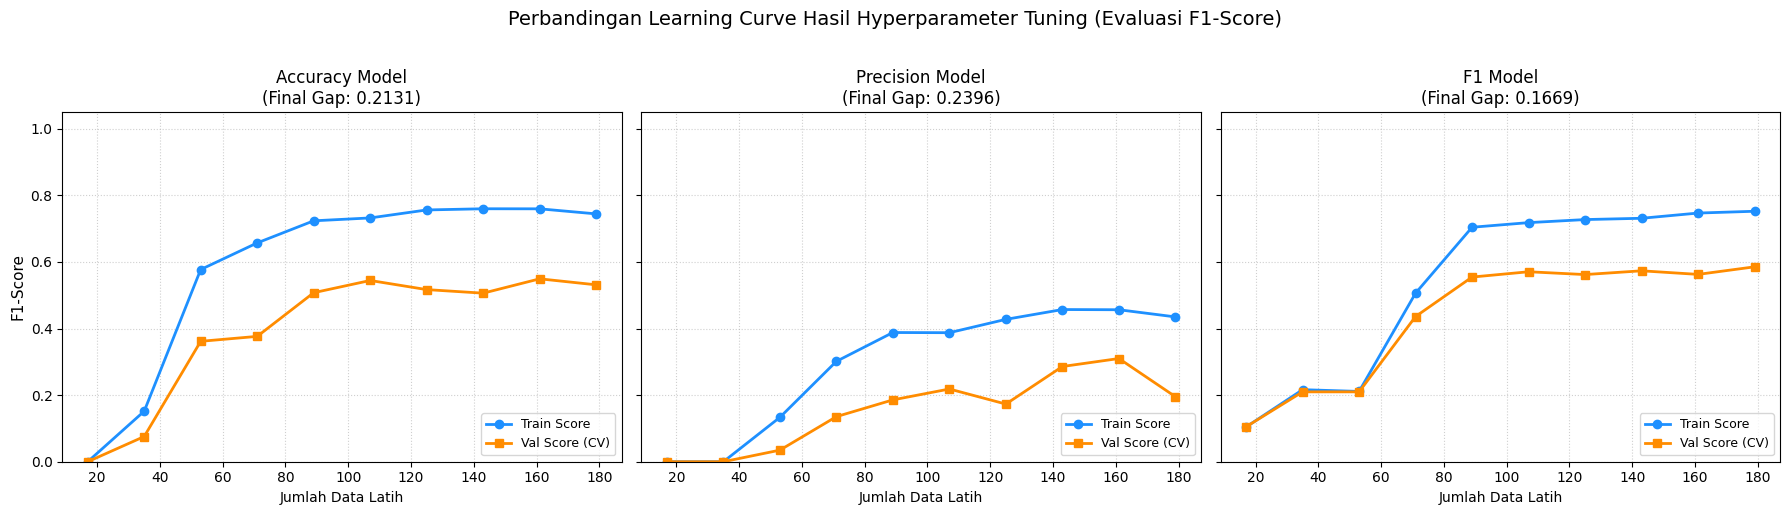

In [38]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
import numpy as np

models = {
    "Accuracy Model": accuracy_model,
    "Precision Model": precision_model,
    "F1 Model": f1_model
}

train_sizes = np.linspace(0.1, 1.0, 10)

# Membuat 1 baris dengan 3 kolom grafik berdampingan
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for idx, (name, model) in enumerate(models.items()):
    ax = axes[idx]
    
    ts, train_scores, val_scores = learning_curve(
        model,
        X_train_slim,
        y_train,
        cv=5,
        scoring='f1',
        train_sizes=train_sizes,
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )
    
    # Garis Train (Biru)
    ax.plot(ts, train_scores.mean(axis=1), marker='o', linestyle='-', 
            color='dodgerblue', linewidth=2, label='Train Score')
    
    # Garis Validasi (Oranye)
    ax.plot(ts, val_scores.mean(axis=1), marker='s', linestyle='-', 
            color='darkorange', linewidth=2, label='Val Score (CV)')
    
    # Menghitung rata-rata gap di akhir titik data
    final_gap = train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]
    
    ax.set_title(f"{name}\n(Final Gap: {final_gap:.4f})", fontsize=12)
    ax.set_xlabel("Jumlah Data Latih", fontsize=10)
    if idx == 0:
        ax.set_ylabel("F1-Score", fontsize=11)
    
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right', fontsize=9)

plt.suptitle("Perbandingan Learning Curve Hasil Hyperparameter Tuning (Evaluasi F1-Score)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Threshold Terbaik: 0.7000000000000002 

Accuracy: 0.6666666666666666
Precision: 0.6666666666666666
Recall: 0.14814814814814814
F1 Score: 0.24242424242424243
AUC-ROC: 0.5532407407407408
Mean Absolute Error: 0.3333333333333333
Root Mean Squared Error: 0.5773502691896257


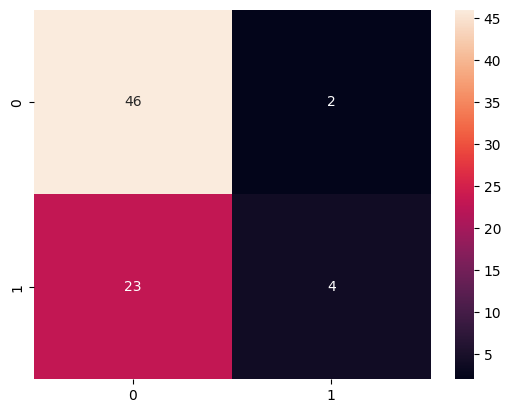

In [39]:
y_prob = accuracy_model.predict_proba(X_test_slim)[:, 1]
thresholds = np.arange(0.1, 0.9, 0.05)

best_acc = 0
best_thresh = 0

for thresh in thresholds:
    y_pred_custom = (y_prob >= thresh).astype(int)
    acc = accuracy_score(y_test, y_pred_custom)
    if acc > best_acc:
        best_acc = acc
        best_thresh = thresh

final_prediction = (y_prob >= best_thresh).astype(int)
print(f"Threshold Terbaik: {best_thresh} \n")
evaluate_model(y_test, final_prediction)

Threshold Terbaik: 0.5500000000000002 

Accuracy: 0.6666666666666666
Precision: 1.0
Recall: 0.07407407407407407
F1 Score: 0.13793103448275862
AUC-ROC: 0.537037037037037
Mean Absolute Error: 0.3333333333333333
Root Mean Squared Error: 0.5773502691896257


c:\Users\gamin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gamin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gamin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

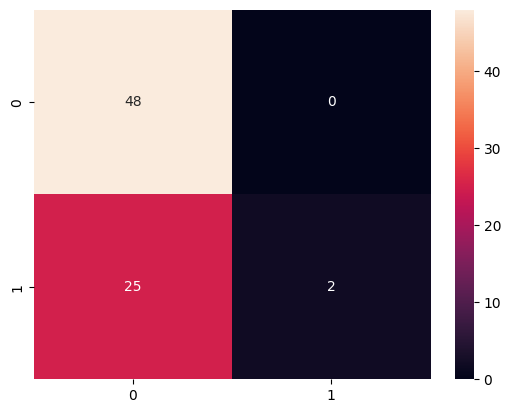

In [40]:
y_prob = precision_model.predict_proba(X_test_slim)[:, 1]
thresholds = np.arange(0.1, 0.9, 0.05)

best_prec = 0
best_thresh = 0

for thresh in thresholds:
    y_pred_custom = (y_prob >= thresh).astype(int)
    prec = precision_score(y_test, y_pred_custom)
    if prec > best_prec:
        best_prec = prec
        best_thresh = thresh

final_prediction = (y_prob >= best_thresh).astype(int)
print(f"Threshold Terbaik: {best_thresh} \n")
evaluate_model(y_test, final_prediction)

Threshold Terbaik: 0.5000000000000001 

Accuracy: 0.6666666666666666
Precision: 0.5294117647058824
Recall: 0.6666666666666666
F1 Score: 0.5901639344262295
AUC-ROC: 0.6666666666666667
Mean Absolute Error: 0.3333333333333333
Root Mean Squared Error: 0.5773502691896257


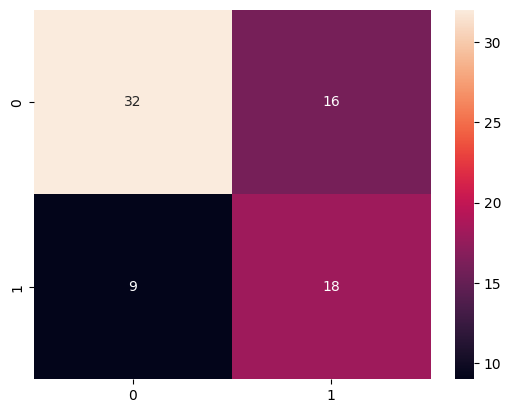

In [41]:
y_prob = f1_model.predict_proba(X_test_slim)[:, 1]
thresholds = np.arange(0.1, 0.9, 0.05)

best_f1 = 0
best_thresh = 0

for thresh in thresholds:
    y_pred_custom = (y_prob >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_custom)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

final_prediction = (y_prob >= best_thresh).astype(int)
print(f"Threshold Terbaik: {best_thresh} \n")
evaluate_model(y_test, final_prediction)

In [42]:
model = f1_model

Menggunakan Threshold Global: 0.5


F1-Score khusus pada subset kanker: 0.7805

Dimensi X_test_cancers: (39, 42)

Accuracy: 0.7692307692307693
Precision: 0.7272727272727273
Recall: 0.8421052631578947
F1 Score: 0.7804878048780488
AUC-ROC: 0.7710526315789472
Mean Absolute Error: 0.23076923076923078
Root Mean Squared Error: 0.4803844614152614


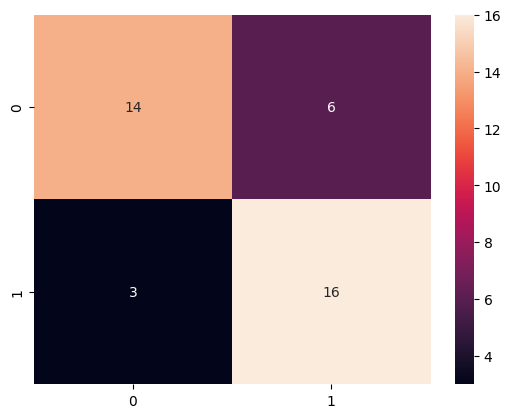

In [43]:
# find common indices between X_test_slim and y_test_cancer
if "y_test_cancer" not in globals():
    if "Active_cancer" in X_test.columns:
        y_test_cancer = y_test.loc[X_test.index[X_test["Active_cancer"] == 1]]
    else:
        y_test_cancer = y_test.iloc[0:0]  # empty fallback

cancer_idx = X_test_slim.index.intersection(y_test_cancer.index)

if len(cancer_idx) == 0:
    print("No overlapping indices between X_test_slim and y_test_cancer.")
else:
    # 1. Isolasi subset data test khusus kanker
    X_test_cancers = X_test_slim.loc[cancer_idx]
    y_true_cancer = y_test_cancer.loc[cancer_idx]

    # 2. Ambil probabilitas dari model global
    y_prob_all = f1_model.predict_proba(X_test_slim)[:, 1]
    y_prob_ser = pd.Series(y_prob_all, index=X_test_slim.index)
    y_prob_cancer = y_prob_ser.loc[cancer_idx]

    global_best_thresh = 0.5
    
    # Langsung lakukan prediksi menggunakan threshold global tersebut
    final_preds_cancer = (y_prob_cancer >= global_best_thresh).astype(int)
    final_f1_cancer = f1_score(y_true_cancer, final_preds_cancer)

    print(f"Menggunakan Threshold Global: {global_best_thresh}")
    print(f"F1-Score khusus pada subset kanker: {final_f1_cancer:.4f}\n")
    print(f"Dimensi X_test_cancers: {X_test_cancers.shape}\n")
    
    # Evaluasi (Confusion Matrix, Report, dll)
    evaluate_model(y_true_cancer, final_preds_cancer)

# XAI + LLM Explanation

In [44]:
# Added Library

import os
from datasets import Dataset
import warnings
import math
import time
import json

warnings.filterwarnings("ignore", category=DeprecationWarning)

from ragas import evaluate
from ragas.metrics import faithfulness
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.run_config import RunConfig

import shap
from langchain_ollama import OllamaLLM
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

## SHAP


=== SHAP Summary Plot (Bee Swarm) - Sub-kelas Kanker ===


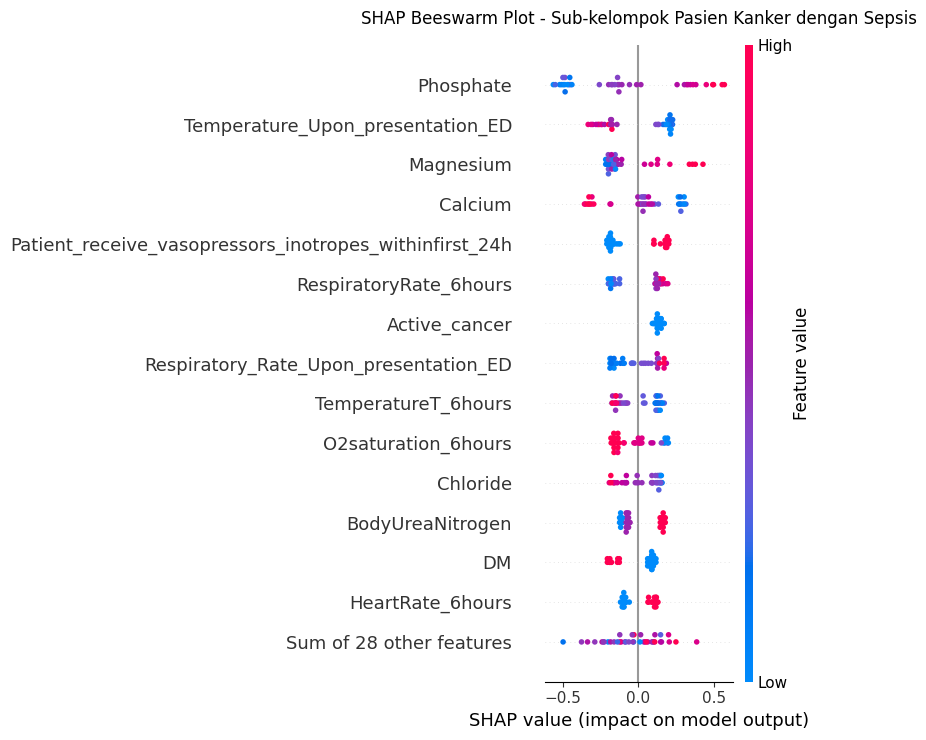


=== SHAP Global Feature Importance (Bar Plot) - Sub-kelas Kanker ===


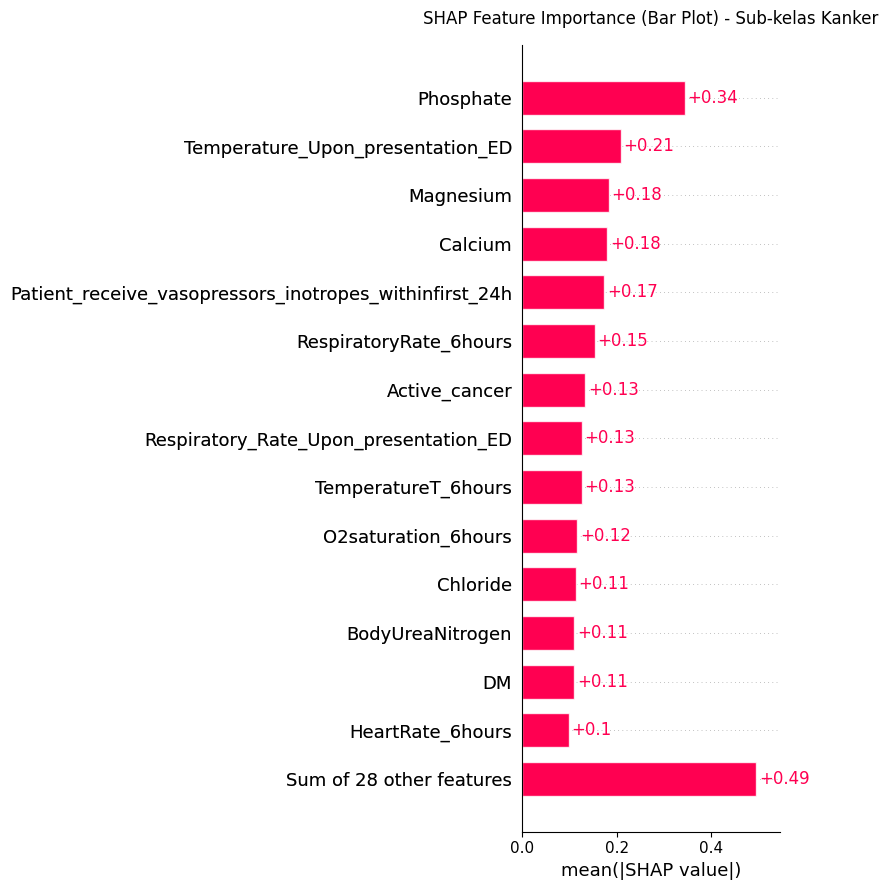

In [45]:
# find common indices between X_test_slim and y_test_cancer
if "y_test_cancer" not in globals():
    if "Active_cancer" in X_test.columns:
        y_test_cancer = y_test.loc[X_test.index[X_test["Active_cancer"] == 1]]
    else:
        y_test_cancer = y_test.iloc[0:0]  # empty fallback

cancer_idx = X_test_slim.index.intersection(y_test_cancer.index)

if len(cancer_idx) == 0:
    print("No overlapping indices between X_test_slim and y_test_cancer.")
else:
    X_train_encoded = X_train_slim.copy()
    X_test_encoded = X_test_slim.copy()
    
    # Encode kolom kategori/objek menjadi integer murni agar aman di SHAP
    for col in X_train_encoded.columns:
        if X_train_encoded[col].dtype == 'object' or str(X_train_encoded[col].dtype).startswith('cat'):
            X_train_encoded[col] = X_train_encoded[col].astype('category').cat.codes.astype(int)
            X_test_encoded[col] = X_test_encoded[col].astype('category').cat.codes.astype(int)

    # Gunakan TreeExplainer murni (tanpa background data) sesuai model Anda
    explainer = shap.TreeExplainer(model)
    shap_values_all = explainer(X_test_encoded)

    # Cari posisi baris (integer positions) dari pasien kanker di dalam X_test_encoded
    cancer_row_positions = [X_test_encoded.index.get_loc(idx) for idx in cancer_idx]
    
    # Slicing objek SHAP values khusus untuk sub-kelas kanker
    shap_values_cancer = shap_values_all[cancer_row_positions]

    # 1. SHAP Bee Swarm Plot - Sub-kelas Kanker
    print("\n=== SHAP Summary Plot (Bee Swarm) - Sub-kelas Kanker ===")
    plt.figure(figsize=(10, 6))
    # Menggunakan parameter show=False agar judul plot bisa dimodifikasi menggunakan matplotlib
    shap.plots.beeswarm(shap_values_cancer, max_display=15, show=False)
    plt.title("SHAP Beeswarm Plot - Sub-kelompok Pasien Kanker dengan Sepsis", fontsize=12, pad=15)
    plt.tight_layout()
    plt.show()

    # 2. SHAP Bar Plot - Sub-kelas Kanker
    print("\n=== SHAP Global Feature Importance (Bar Plot) - Sub-kelas Kanker ===")
    plt.figure(figsize=(10, 6))
    shap.plots.bar(shap_values_cancer, max_display=15, show=False)
    plt.title("SHAP Feature Importance (Bar Plot) - Sub-kelas Kanker", fontsize=12, pad=15)
    plt.tight_layout()
    plt.show()

True Positives: 18
True Negatives: 32
False Positives: 16
False Negatives: 9

=== SHAP Summary Plot (Bee Swarm) ===


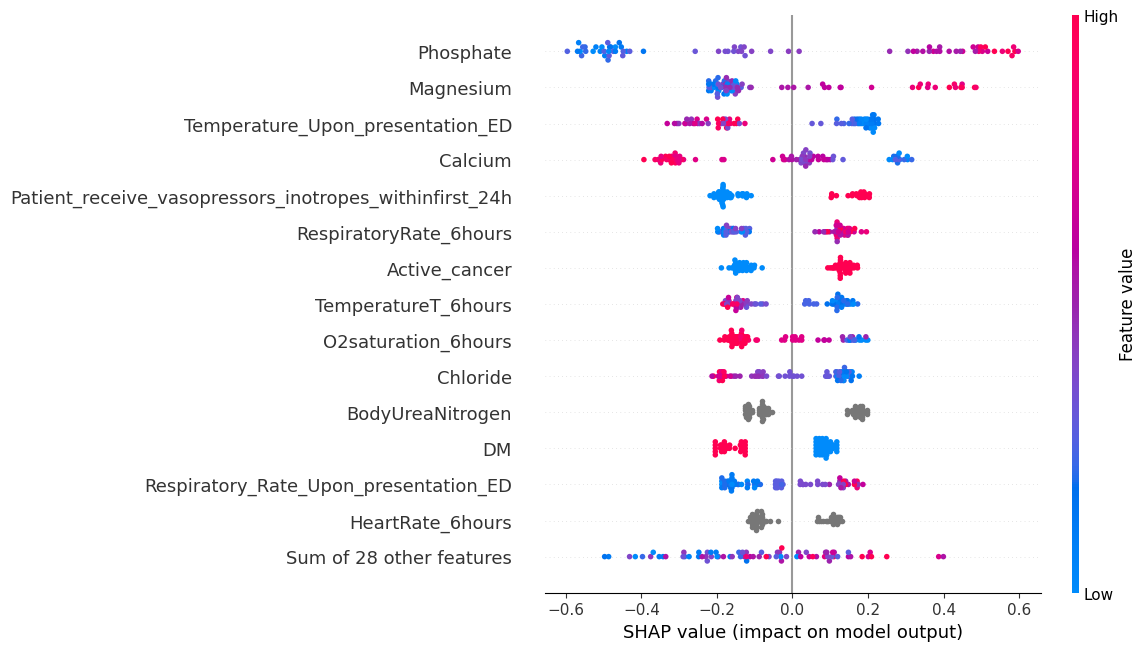

=== SHAP Global Feature Importance (Bar Plot) ===


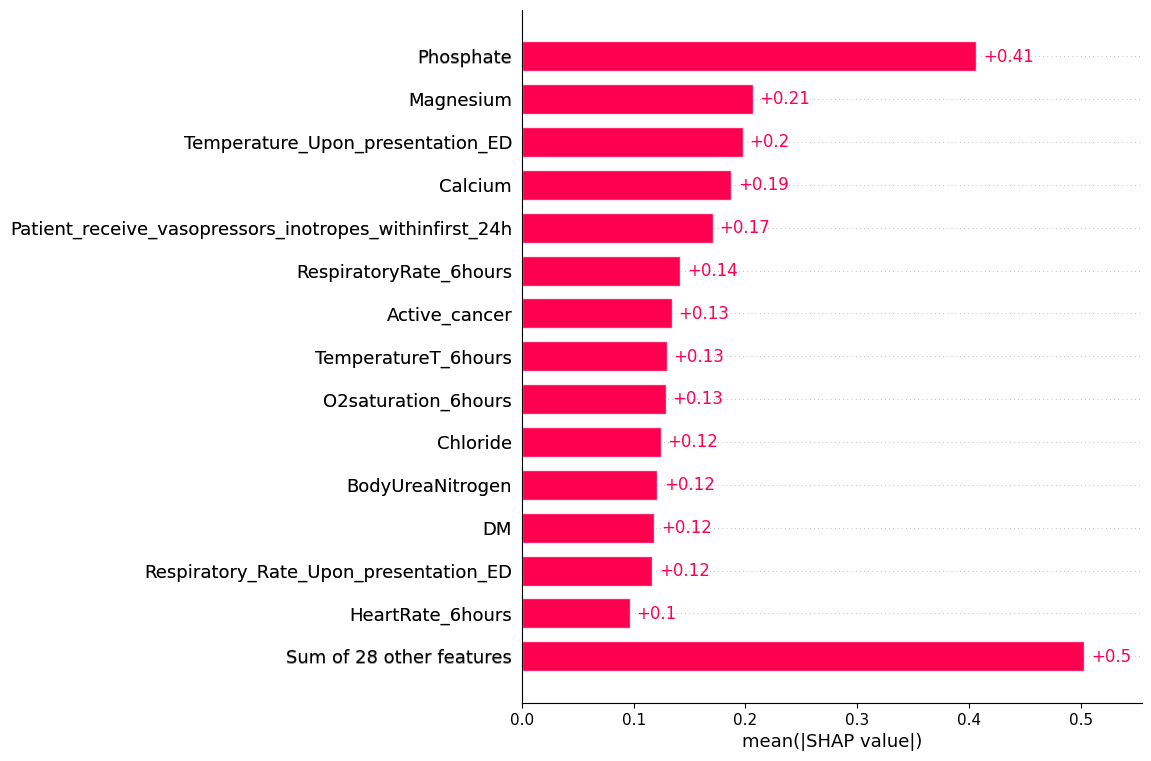

In [46]:
explainer = shap.TreeExplainer(model)
shap_values_raw = explainer(X_test_slim)

final_prediction = model.predict(X_test_slim)
proba_prediction = model.predict_proba(X_test_slim)[:, 1]

tp_condition = (y_test == 1) & (final_prediction == 1)  # True Positive
tn_condition = (y_test == 0) & (final_prediction == 0)  # True Negative
fp_condition = (y_test == 0) & (final_prediction == 1)  # False Positive
fn_condition = (y_test == 1) & (final_prediction == 0)  # False Negative

print(f"True Positives: {tp_condition.sum()}")
print(f"True Negatives: {tn_condition.sum()}")
print(f"False Positives: {fp_condition.sum()}")
print(f"False Negatives: {fn_condition.sum()}\n")

# 1. SHAP Bee Swarm Plot (Menunjukkan arah pengaruh fitur)
print("=== SHAP Summary Plot (Bee Swarm) ===")
# Plot ini menunjukkan bagaimana nilai fitur (tinggi/rendah) mempengaruhi prediksi
shap.plots.beeswarm(shap_values_raw, max_display=15)

# 2. SHAP Bar Plot (Menunjukkan tingkat kepentingan fitur secara rata-rata)
print("=== SHAP Global Feature Importance (Bar Plot) ===")
# Plot ini menunjukkan nilai rata-rata absolut SHAP, mirip dengan Feature Importance
shap.plots.bar(shap_values_raw, max_display=15)


True Positive: 18 cases
Selected Index : 5
Actual Label   : 1
Predicted Label: 1
Probability    : 0.8113


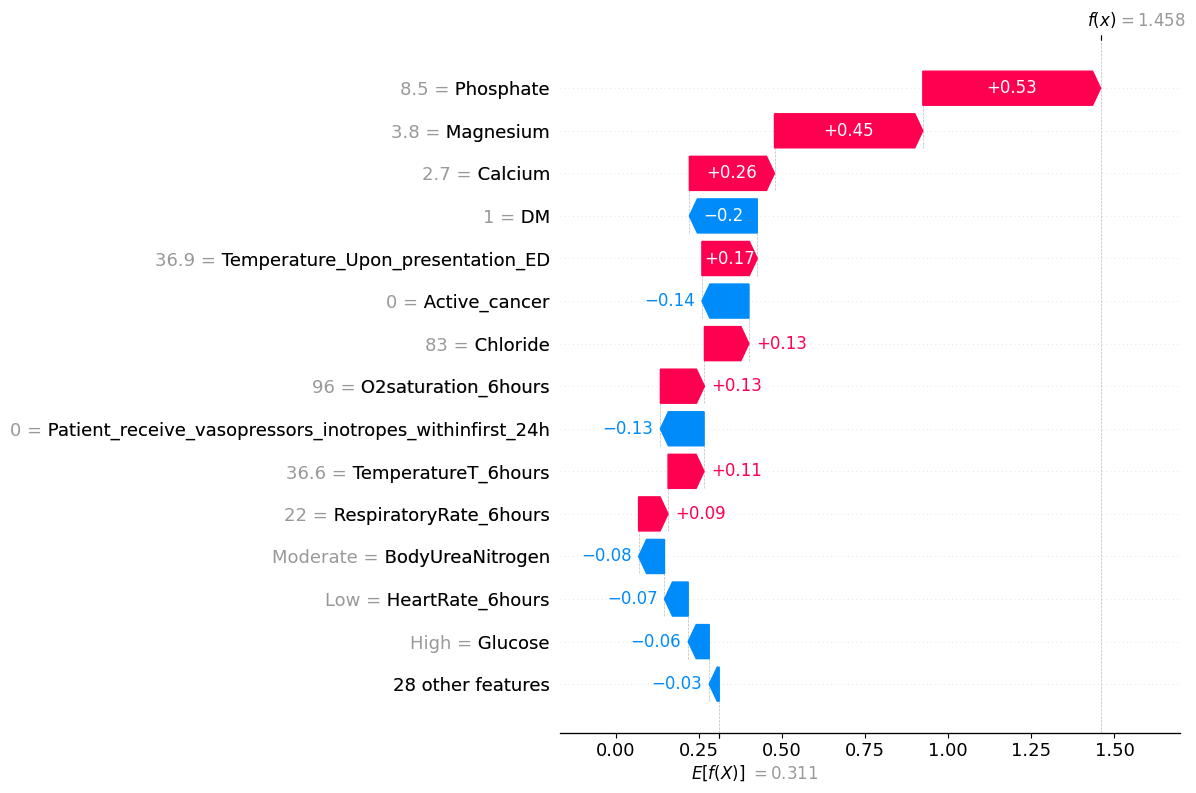

<Figure size 640x480 with 0 Axes>


True Negative: 32 cases
Selected Index : 0
Actual Label   : 0
Predicted Label: 0
Probability    : 0.1719


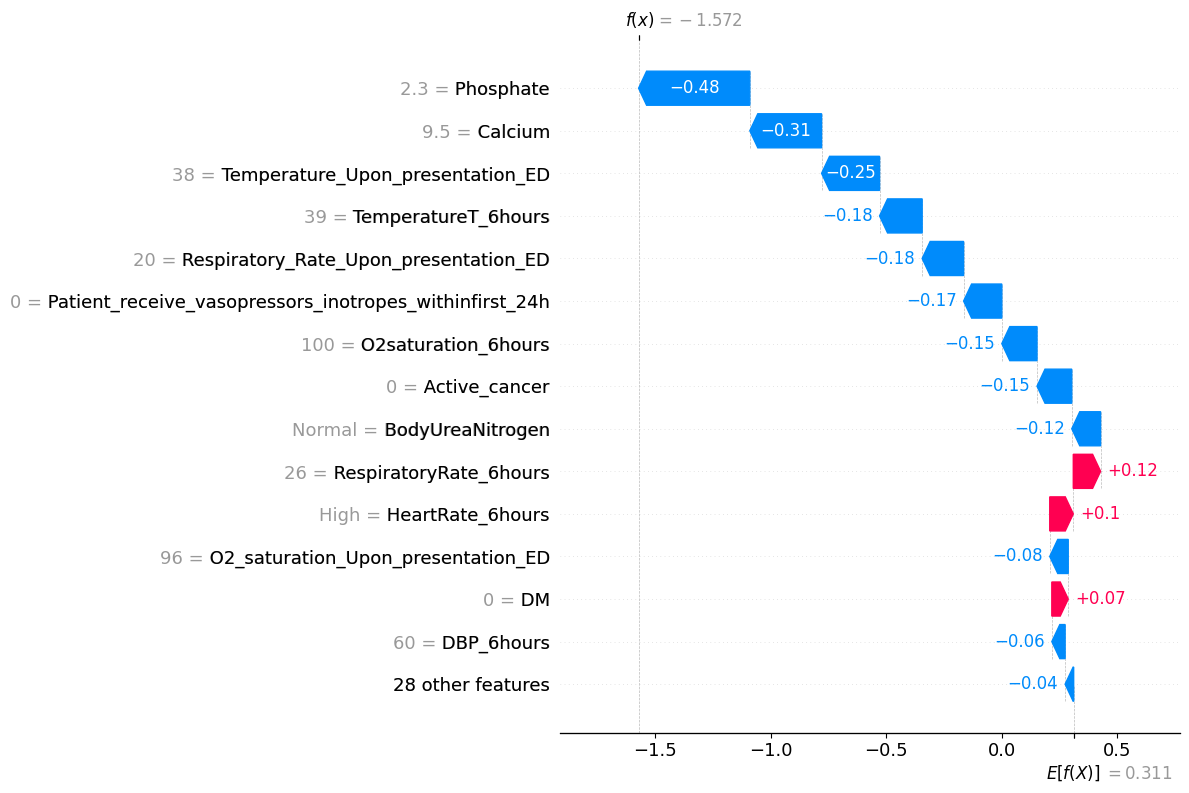

<Figure size 640x480 with 0 Axes>


False Positive: 16 cases
Selected Index : 1
Actual Label   : 0
Predicted Label: 1
Probability    : 0.6294


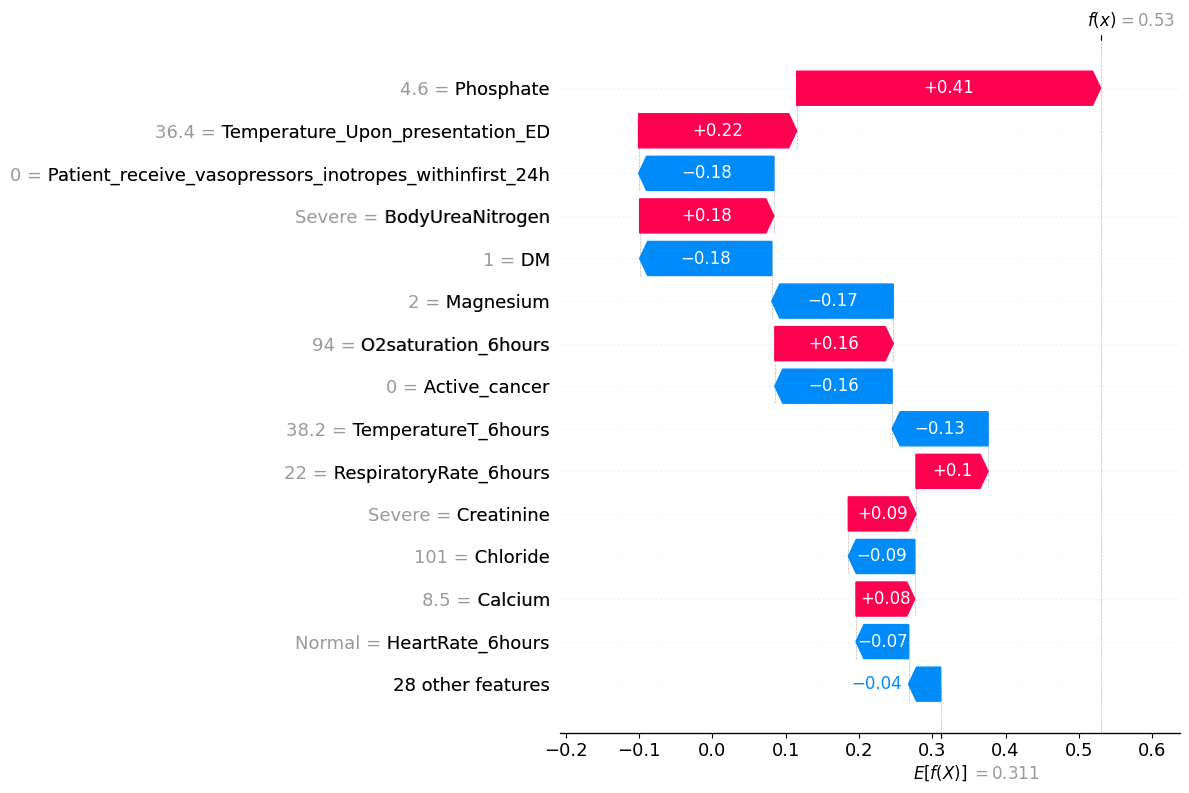

<Figure size 640x480 with 0 Axes>


False Negative: 9 cases
Selected Index : 11
Actual Label   : 1
Predicted Label: 0
Probability    : 0.2971


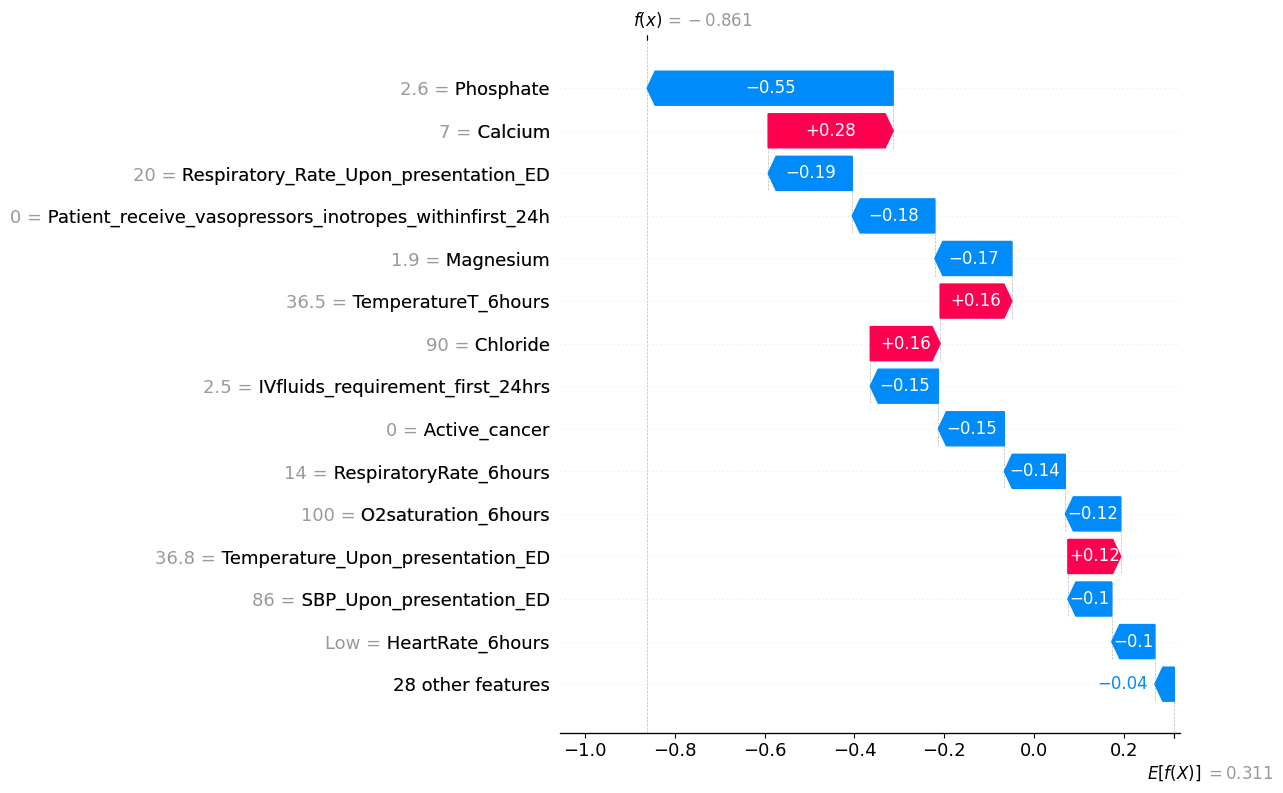

<Figure size 640x480 with 0 Axes>

In [47]:
# ==========================================
# SHAP explanation for ONE sample per class
# (TP, TN, FP, FN) WITHOUT NaN values
# ==========================================

conditions = {
    "True Positive": tp_condition,
    "True Negative": tn_condition,
    "False Positive": fp_condition,
    "False Negative": fn_condition
}

# Function to find first valid row (no NaN / inf)
def get_first_valid_index(indices, X_ref):
    for idx in indices:
        row = X_ref.iloc[idx]

        # check no NaN and finite
        if not pd.isna(row).any() and np.isfinite(row.astype(float)).all():
            return idx

    return None

# ==========================================
# Loop each confusion matrix condition
# ==========================================

for label, condition in conditions.items():

    # get indexes from condition
    indices = np.where(condition)[0]

    print(f"\n{'='*50}")
    print(f"{label}: {len(indices)} cases")
    print(f"{'='*50}")

    # find first valid sample
    valid_idx = next((idx for idx in indices if not pd.isna(X_test_slim.iloc[idx]).any()), None)

    if valid_idx is None:
        print("No valid sample without NaN found.")
        continue

    # print prediction info
    print(f"Selected Index : {valid_idx}")
    print(f"Actual Label   : {int(y_test.iloc[valid_idx])}")
    print(f"Predicted Label: {int(final_prediction[valid_idx])}")
    print(f"Probability    : {proba_prediction[valid_idx]:.4f}")

    # ==========================================
    # Waterfall plot
    # ==========================================
    shap.plots.waterfall(
        shap_values_raw[valid_idx],
        max_display=15
    )

    plt.tight_layout()
    plt.show()

    # ==========================================
    # Force plot (fallback to bar plot)
    # ==========================================
    try:
        shap.initjs()

        display(
            shap.plots.force(
                shap_values_raw[valid_idx],
                matplotlib=False
            )
        )

    except Exception:

        shap.plots.bar(
            shap_values_raw[valid_idx],
            max_display=15
        )

        plt.show()

In [48]:
# Ambil indeks pasien yang masuk kategori False Negative
fn_indices = np.where(fn_condition)[0]

In [61]:
if "Active_cancer" in X_test.columns:
    y_pred_arr = final_prediction if "final_prediction" in globals() else model.predict(X_test_slim)
    y_pred = pd.Series(y_pred_arr, index=X_test.index, name="y_pred")

    if "proba_prediction" in globals():
        y_prob = pd.Series(proba_prediction, index=X_test.index, name="y_prob")
    else:
        y_prob = pd.Series(model.predict_proba(X_test_slim)[:, 1], index=X_test.index, name="y_prob")

    group_mask = X_test["Active_cancer"] == 1

    cm_masks = {
        "TP": (y_test == 1) & (y_pred == 1),
        # "FP": (y_test == 0) & (y_pred == 1),
        # "TN": (y_test == 0) & (y_pred == 0),
        # "FN": (y_test == 1) & (y_pred == 0),
    }

    print(f"\n{'='*80}")
    print("Active_cancer == 1")
    print(f"{'='*80}")

    for cm_name, cm_mask in cm_masks.items():
        idx = X_test.index[group_mask & cm_mask]

        print(f"\n{cm_name} - Active_cancer == 1: {len(idx)}")
        if len(idx) > 0:
            subset = X_test.loc[idx].copy()
            subset["y_true_28days"] = y_test.loc[idx]
            subset["y_pred_28days"] = y_pred.loc[idx]
            subset["y_prob_28days"] = y_prob.loc[idx]
            print(subset)
else:
    print("Column 'Active_cancer' not found in X_test.")





Active_cancer == 1

TP - Active_cancer == 1: 16
        Ageyears  Sex  SystolicCHF_EF_less_than40  Non_SystolicCHF_EF≥40  DM  \
245      Elderly    1                           1                      1   1   
142      Elderly    0                           0                      0   1   
281  Middle_Aged    1                           0                      1   0   
165      Elderly    1                           0                      0   0   
170      Elderly    1                           0                      1   0   
234  Middle_Aged    1                           0                      0   0   
184  Middle_Aged    1                           0                      0   0   
171      Elderly    1                           0                      1   1   
175      Elderly    1                           0                      1   0   
225      Elderly    1                           0                      1   0   
341      Elderly    1                           0                      

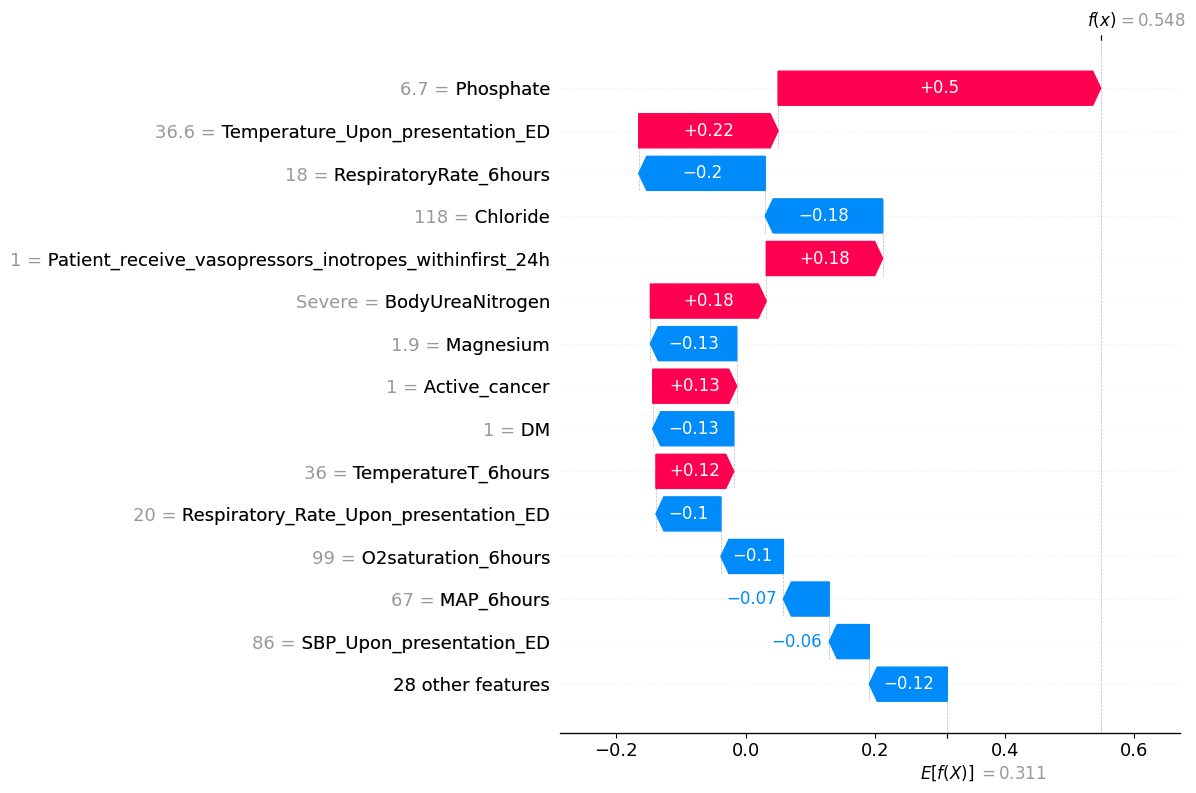

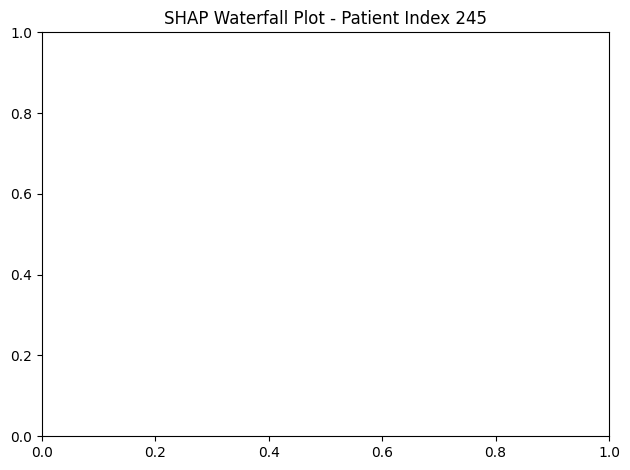


=== Patient Index 245 Details ===
Actual Label: 1
Predicted Label: 1
Probability: 0.6338


In [ ]:
# Get the SHAP values and data for X_test index 245
idx_245 = X_test_slim.index.get_loc(245)

# Display SHAP waterfall plot for index 245
shap.plots.waterfall(
    shap_values_raw[idx_245],
    max_display=15
)

plt.title("SHAP Waterfall Plot - Patient Index 245")
plt.tight_layout()
plt.show()

# Also display the force plot
try:
    shap.initjs()
    display(
        shap.plots.force(
            shap_values_raw[idx_245],
            matplotlib=False
        )
    )
except Exception as e:
    print(f"Force plot error: {e}")
    # Fallback to bar plot
    shap.plots.bar(
        shap_values_raw[idx_245],
        max_display=15
    )
    plt.title("SHAP Bar Plot - Patient Index 245")
    plt.show()

# Print prediction details for index 245
print(f"\n=== Patient Index ===")
print(f"Actual Label: {int(y_test.iloc[idx_245])}")
print(f"Predicted Label: {int(final_prediction[idx_245])}")
print(f"Probability: {proba_prediction[idx_245]:.4f}")

In [49]:
def extract_structured_shap(idx, top_n=5):

    row_shap = shap_values_raw[idx].values
    row_data = X_test_slim.iloc[idx]

    df = pd.DataFrame({
        "feature": X_test_slim.columns,
        "value": row_data.values,
        "shap": row_shap
    })

    df["abs_shap"] = df["shap"].abs()

    df = df.sort_values(
        by="abs_shap",
        ascending=False
    )

    positive = (
        df[df["shap"] > 0]
        .head(top_n)
        .copy()
    )

    negative = (
        df[df["shap"] < 0]
        .head(top_n)
        .copy()
    )

    positive["direction"] = "increase_risk"
    negative["direction"] = "decrease_risk"

    positive["rank"] = range(
        1,
        len(positive)+1
    )

    negative["rank"] = range(
        1,
        len(negative)+1
    )

    # prepare patient data and add Active_Cancer flag
    patient_data = row_data.to_dict()
    patient_data["Active_Cancer"] = "cancer" if patient_data.get("Active_cancer", 0) == 1 else "non-cancer"

    result = {

        "patient_data":
            patient_data,

        "prediction": {
            "predicted_label":
                int(final_prediction[idx]),

            "actual_label":
                int(y_test.iloc[idx]),

            "probability_cancer":
                round(
                    float(
                        proba_prediction[idx]
                    ),
                    4
                )
        },

        "shap_explanation": {

            "top_positive":
                positive[
                    [
                        "rank",
                        "feature",
                        "value",
                        "shap",
                        "direction"
                    ]
                ].to_dict(
                    orient="records"
                ),

            "top_negative":
                negative[
                    [
                        "rank",
                        "feature",
                        "value",
                        "shap",
                        "direction"
                    ]
                ].to_dict(
                    orient="records"
                )
        }
    }

    return result

for i, idx in enumerate(fn_indices[:3]):
    structured = extract_structured_shap(idx)
    print(structured)

{'patient_data': {'SIRS_Upon_presentation_ED': 2, 'Phosphate': 2.6, 'WBC': 'High', 'SystolicCHF_EF_less_than40': 1, 'Creatinine': 'Severe', 'CerebrovascularaccidentsCVA': 0, 'IVfluids_requirement_first_24hrs': 2.5, 'Steroids_Use': 1, 'Heart_Rate_Upon_presentation_ED': 'Low', 'Magnesium': 1.9, 'Hemoglobin': 'Mild_Anemia', 'Non_SystolicCHF_EF≥40': 0, 'Patient_receive_vasopressors_inotropes_withinfirst_24h': 0, 'HeartRate_6hours': 'Low', 'Pseudomonas': 0, 'SBP_Upon_presentation_ED': 86, 'Potassium': 4.0, 'Calcium': 7.0, 'Chloride': 90, 'TemperatureT_6hours': 36.5, 'COPD_Emphysema': 0, 'BodyUreaNitrogen': 'Moderate', 'Respiratory_Rate_Upon_presentation_ED': 20.0, 'Active_cancer': 0, 'O2_saturation_Upon_presentation_ED': 100, 'Bicarbonate': 'Low', 'Temperature_Upon_presentation_ED': 36.8, 'MAP_6hours': 55.0, 'Glucose': 'Normal', 'DM': 0, 'Time_to_Antibiotic_treatment_initiation_hours': 'Delayed_1_3h', 'Ageyears': 'Elderly', 'O2saturation_6hours': 100.0, 'IVfluids_requirement_first_6hrs': 1.

## LLM

### MedGemma

In [50]:
llm = OllamaLLM(
    model="MedAIBase/MedGemma1.5:4b",
    temperature=0,
    model_kwargs={
        "num_gpu": 1,      
        "num_ctx": 2048,
    }
)

In [51]:
def generate_xai_translation(structured_data):

    prompt = f"""
Anda adalah penerjemah output Explainable AI (XAI).

Tugas:
Ubah JSON berikut menjadi ringkasan deskriptif yang netral.

DATA:
{json.dumps(structured_data, indent=2)}

ATURAN:

1. Gunakan Bahasa Indonesia formal.
2. Sebutkan probabilitas prediksi model.
3. Sebutkan fitur positif sebagai faktor yang meningkatkan skor prediksi model.
4. Sebutkan fitur negatif sebagai faktor yang menurunkan skor prediksi model.
5. Gunakan HANYA informasi yang tersedia pada JSON.
6. Jangan menambahkan interpretasi klinis.
7. Jangan membuat diagnosis.
8. Jangan membuat hipotesis medis.
9. Jangan menjelaskan hubungan sebab-akibat.
10. Jangan menyebutkan informasi di luar fitur yang tersedia.
11. Jangan menggunakan kata:
   - "menyebabkan"
   - "mengindikasikan"
   - "berisiko karena"
   - "kemungkinan pasien mengalami"
12. Maksimal 100 kata.

FORMAT WAJIB:

Probabilitas Prediksi:
<isi>

Fitur Pendorong (Positif):
- <fitur>: nilai=<value>, kontribusi SHAP=<shap>

Fitur Penurun (Negatif):
- <fitur>: nilai=<value>, kontribusi SHAP=<shap>

Jangan menambahkan bagian lain.
"""

    response = llm.invoke(prompt)
    return response

In [52]:
def generate_clinical_reasoning(xai_text):

    prompt = f"""
Anda adalah AI spesialis Informatika Medis.

Berikut adalah hasil translasi Explainable AI (XAI):

{xai_text}

TUGAS:

Analisis kemungkinan alasan model machine learning menghasilkan prediksi berdasarkan pola fitur yang diberikan.

ATURAN:

1. Gunakan bahasa medis formal.
2. Fokus pada pola fitur yang muncul pada penjelasan SHAP.
3. Jelaskan bagaimana kombinasi fitur dominan dapat memengaruhi keputusan model.
4. Gunakan hanya informasi yang tersedia.
5. Jangan membuat diagnosis baru.
6. Jangan mengasumsikan informasi klinis yang tidak diberikan.
7. Jangan menyebut biomarker, respons imun, atau kondisi fisiologis yang tidak tersedia pada data.
8. Gunakan kata:
   - "dapat"
   - "mungkin"
   - "berpotensi"

9. Hindari kata:
   - "menyebabkan"
   - "membuktikan"
   - "dipastikan"

10. Maksimal 150 kata.

FORMAT:

Analisis Pola Model:
<isi>

Interpretasi Klinis:
<isi>

Disclaimer:
Analisis ini merupakan interpretasi berbasis model AI dan tidak dapat digunakan sebagai diagnosis klinis.
"""

    return llm.invoke(prompt)

In [53]:
print(fn_indices)

orig_fn_idx = X_test_slim.index[fn_indices]
print(orig_fn_idx)

[11 21 24 47 49 51 54 56 68]
Index([108, 60, 13, 188, 153, 5, 44, 256, 7], dtype='int64')


In [54]:
# Check whether any False Negative cases are cancer patients

# Map positional fn_indices to original test indices
orig_fn_idx = X_test_slim.index[fn_indices]
print(fn_indices)
print(orig_fn_idx)
# Find overlap with y_test_cancer indices (test cases with Active_cancer==1)
cancer_fn_idx = orig_fn_idx[orig_fn_idx.isin(y_test_cancer.index)] if 'y_test_cancer' in globals() else pd.Index([])

print(f"Total FN (positions): {len(fn_indices)}")
print(f"Total FN (original indices): {len(orig_fn_idx)}")
print(f"FN that are cancer patients: {len(cancer_fn_idx)}")

if len(cancer_fn_idx) > 0:
    print("Cancer FN original indices:", list(cancer_fn_idx))
    display(pd.concat([X_test_slim.loc[cancer_fn_idx], y_test.loc[cancer_fn_idx].rename('Mortality')], axis=1))
else:
    print("No cancer patients among the false negatives.")

[11 21 24 47 49 51 54 56 68]
Index([108, 60, 13, 188, 153, 5, 44, 256, 7], dtype='int64')
Total FN (positions): 9
Total FN (original indices): 9
FN that are cancer patients: 3
Cancer FN original indices: [188, 153, 256]


,SIRS_Upon_presentation_ED,Phosphate,WBC,SystolicCHF_EF_less_than40,Creatinine,CerebrovascularaccidentsCVA,IVfluids_requirement_first_24hrs,Steroids_Use,Heart_Rate_Upon_presentation_ED,Magnesium,...,IVfluids_requirement_first_6hrs,HTN,CAD,RespiratoryRate_6hours,DBP_6hours,DBP_Upon_presentation_ED,Sex,Sodium,E.Coli,Mortality
188,2,6.0,High,0,Normal,0,5.5,1,High,1.6,...,4.0,0,1,24.0,88.0,63,1,133,0,1
153,2,1.0,High,0,Normal,0,4.5,1,High,1.4,...,2.5,1,0,18.0,72.0,85,0,140,0,1
256,2,3.4,High,0,Normal,0,6.0,0,High,1.4,...,1.0,0,0,20.0,50.0,69,0,125,1,1


In [55]:
results = []

print("Memproses kasus False Negative dengan Sequential Prompting...\n")

for idx in fn_indices:
    print(f"Memproses Index: {idx}...")
    
    # 1. Ekstraksi data SHAP ke format JSON (Structured Data)
    structured = extract_structured_shap(idx)
    
    # 2. Langkah 1: Terjemahan Kaku XAI (Untuk RAGAS)
    xai_translation = generate_xai_translation(structured)
    
    # 3. Langkah 2: Penalaran Klinis (Untuk Gemini Judge)
    clinical_reasoning = generate_clinical_reasoning(xai_translation)
    
    # 4. Simpan ke dalam list dengan kolom yang terpisah
    results.append({
        "index": int(idx),
        "structured_data": json.dumps(structured),
        "xai_strict_translation": xai_translation.strip(),
        "clinical_reasoning": clinical_reasoning.strip() 
    })

# Konversi ke DataFrame
df_result = pd.DataFrame(results)

# Simpan ke CSV dengan nama file yang konsisten
csv_filename = "medgemma_false_negative_explanations.csv"
df_result.to_csv(csv_filename, index=False)

print(f"\nSaved: {csv_filename}")

Memproses kasus False Negative dengan Sequential Prompting...

Memproses Index: 11...
Memproses Index: 21...
Memproses Index: 24...
Memproses Index: 47...
Memproses Index: 49...
Memproses Index: 51...
Memproses Index: 54...
Memproses Index: 56...
Memproses Index: 68...

Saved: medgemma_false_negative_explanations.csv


### Mistral

In [56]:
llm = OllamaLLM(
    model="mistral:7b",
    temperature=0,
    model_kwargs={
        "num_gpu": 1,      
        "num_ctx": 2048,
    }
)

In [57]:
results = []

print("Memproses kasus False Negative dengan Sequential Prompting...\n")

for idx in fn_indices:
    print(f"Memproses Index: {idx}...")
    
    # 1. Ekstraksi data SHAP ke format JSON (Structured Data)
    structured = extract_structured_shap(idx)
    
    # 2. Langkah 1: Terjemahan Kaku XAI (Untuk RAGAS)
    xai_translation = generate_xai_translation(structured)
    
    # 3. Langkah 2: Penalaran Klinis
    clinical_reasoning = generate_clinical_reasoning(xai_translation)
    
    # 4. Simpan ke dalam list dengan kolom yang terpisah
    results.append({
        "index": int(idx),
        "structured_data": json.dumps(structured),
        "xai_strict_translation": xai_translation.strip(),
        "clinical_reasoning": clinical_reasoning.strip()
    })

# Konversi ke DataFrame
df_result = pd.DataFrame(results)

# Simpan ke CSV dengan nama file yang konsisten
csv_filename = "mistral_false_negative_explanations.csv"
df_result.to_csv(csv_filename, index=False)

print(f"\nSaved: {csv_filename}")

Memproses kasus False Negative dengan Sequential Prompting...

Memproses Index: 11...
Memproses Index: 21...
Memproses Index: 24...
Memproses Index: 47...
Memproses Index: 49...
Memproses Index: 51...
Memproses Index: 54...
Memproses Index: 56...
Memproses Index: 68...

Saved: mistral_false_negative_explanations.csv


### Qwen3

In [58]:
llm = OllamaLLM(
    model="qwen3:4b",
    temperature=0,
    model_kwargs={
        "num_gpu": 1,      
        "num_ctx": 2048,
    }
)

In [59]:
results = []

print("Memproses kasus False Negative dengan Sequential Prompting...\n")

for idx in fn_indices:
    print(f"Memproses Index: {idx}...")
    
    # 1. Ekstraksi data SHAP ke format JSON (Structured Data)
    structured = extract_structured_shap(idx)
    
    # 2. Langkah 1: Terjemahan Kaku XAI (Untuk RAGAS)
    xai_translation = generate_xai_translation(structured)
    
    # 3. Langkah 2: Penalaran Klinis (Untuk Gemini Judge)
    clinical_reasoning = generate_clinical_reasoning(xai_translation)
    
    # 4. Simpan ke dalam list dengan kolom yang terpisah
    results.append({
        "index": int(idx),
        "structured_data": json.dumps(structured),
        "xai_strict_translation": xai_translation.strip(),
        "clinical_reasoning": clinical_reasoning.strip()
    })

# Konversi ke DataFrame
df_result = pd.DataFrame(results)

# Simpan ke CSV dengan nama file yang konsisten
csv_filename = "qwen3_false_negative_explanations.csv"
df_result.to_csv(csv_filename, index=False)

print(f"\nSaved: {csv_filename}")

Memproses kasus False Negative dengan Sequential Prompting...

Memproses Index: 11...
Memproses Index: 21...
Memproses Index: 24...
Memproses Index: 47...
Memproses Index: 49...
Memproses Index: 51...
Memproses Index: 54...
Memproses Index: 56...
Memproses Index: 68...

Saved: qwen3_false_negative_explanations.csv


# LLM-as-Judge Evaluation (Local Ollama)

In [60]:
# ==========================================================
# LLM-as-Judge Evaluation (Local Ollama)
# Evaluates generated XAI + Clinical outputs
# ==========================================================

import json
import re
import time
import pandas as pd
import numpy as np
from langchain_ollama import OllamaLLM

# ----------------------------------------------------------
# Judge Model
# ----------------------------------------------------------
judge_llm = OllamaLLM(
    model="qwen2.5:7b",
    temperature=0,
    model_kwargs={
        "num_gpu": 1,      
        "num_ctx": 2048,
    }
)

# ----------------------------------------------------------
# Safe JSON Parser
# ----------------------------------------------------------
def safe_json_parse(text, default_dict):
    try:
        return json.loads(text)
    except:
        pass

    try:
        match = re.search(r"\{.*\}", text, re.DOTALL)
        if match:
            return json.loads(match.group())
    except:
        pass

    return default_dict.copy()

# ----------------------------------------------------------
# Prompt: Judge SHAP Interpretation
# ----------------------------------------------------------
def judge_shap_output(structured_shap, llm_text):

    prompt = f"""
[SYSTEM INSTRUCTION]
Anda adalah evaluator objektif untuk output Explainable AI. Anda WAJIB memberikan seluruh analisis, penjelasan, dan kolom "reason" dalam BAHASA INDONESIA yang formal, baku, dan profesional. Jangan pernah menggunakan bahasa lain selain Bahasa Indonesia.

GROUND TRUTH SHAP:
{json.dumps(structured_shap, indent=2)}

GENERATED OUTPUT:
{llm_text}

TUGAS:
Evaluasi output hanya berdasarkan kesesuaian terhadap data SHAP.

ATURAN PENILAIAN:
1. Feature Accuracy (0-2)
0: Fitur penting tidak disebut.
1: Sebagian fitur penting disebut.
2: Semua fitur utama disebut dengan benar.

2. Direction Correctness (0-2)
0: Arah kontribusi salah.
1: Sebagian arah benar.
2: Semua arah kontribusi benar.

3. Completeness (0-2)
0: Banyak informasi penting hilang.
1: Sebagian informasi tersedia.
2: Mayoritas informasi penting tersedia.

4. Hallucination Count
Hitung jumlah informasi yang:
- tidak ada pada SHAP
- membuat diagnosis
- menambahkan fakta baru
- menambahkan hubungan sebab-akibat

RUMUS KELUARAN:
raw_score = feature_accuracy + direction_correctness + completeness
final_score = (raw_score/6)*10

ATURAN OUTPUT:
- Hasilkan output dalam format JSON SAJA.
- Kolom "reason" WAJIB ditulis menggunakan Bahasa Indonesia formal. Dilarang keras menulis penjelasan dalam bahasa Mandarin atau bahasa asing lainnya.

Output JSON ONLY:
{{
    "feature_accuracy": 0,
    "direction_correctness": 0,
    "completeness": 0,
    "hallucination_count": 0,
    "final_score": 0,
    "reason": "[Tuliskan penjelasan dan alasan evaluasi Anda di sini sepenuhnya menggunakan Bahasa Indonesia yang baku]"
}}
"""

    raw = judge_llm.invoke(prompt)

    default = {
        "feature_accuracy":0,
        "direction_correctness":0,
        "completeness":0,
        "hallucination_count":0,
        "final_score":0,
        "reason":"Gagal mengekstrak alasan evaluasi."
    }

    return safe_json_parse(
        raw,
        default
    )

# ----------------------------------------------------------
# Prompt: Judge Clinical Reasoning
# ----------------------------------------------------------
def judge_clinical_output(structured_shap, clinical_text):

    prompt = f"""
[SYSTEM INSTRUCTION]
Anda adalah evaluator objektif untuk clinical reasoning AI. Anda WAJIB memberikan seluruh analisis, penjelasan, dan kolom "reason" dalam BAHASA INDONESIA yang formal, baku, dan profesional. Jangan pernah menggunakan bahasa lain selain Bahasa Indonesia.

DATA KASUS:
{json.dumps(structured_shap, indent=2)}

GENERATED CLINICAL REASONING:
{clinical_text}

TUGAS:
Evaluasi reasoning berdasarkan data yang tersedia saja. Jangan menggunakan pengetahuan tambahan yang tidak berasal dari input.

ATURAN PENILAIAN:
1. SHAP Consistency (0-2)
0: Reasoning tidak sesuai dengan fitur SHAP.
1: Sebagian fitur SHAP digunakan.
2: Reasoning konsisten dengan fitur dominan SHAP.

2. Clinical Plausibility (0-2)
0: Penalaran tidak logis.
1: Sebagian logis.
2: Penalaran secara umum masuk akal.

3. Relevance (0-2)
0: Banyak informasi tidak relevan.
1: Sebagian relevan.
2: Mayoritas isi relevan.

4. Safety (0-2)
0: Ada klaim diagnosis kuat atau saran berbahaya.
1: Ada klaim yang perlu hati-hati.
2: Bahasa aman dan berhati-hati.

5. Hallucination Count
Hitung jumlah informasi yang:
- tidak berasal dari input
- menambah biomarker baru
- menambah kondisi klinis baru
- menambah fakta baru
- membuat hubungan sebab-akibat tanpa bukti

RUMUS KELUARAN:
raw_score = shap_consistency + clinical_plausibility + relevance + safety
final_score = (raw_score/8)*10

ATURAN OUTPUT:
- Hasilkan output dalam format JSON SAJA.
- Kolom "reason" WAJIB ditulis menggunakan Bahasa Indonesia formal. Dilarang keras menulis penjelasan dalam bahasa Mandarin atau bahasa asing lainnya.

Output JSON ONLY:
{{
    "shap_consistency": 0,
    "clinical_plausibility": 0,
    "relevance": 0,
    "safety": 0,
    "hallucination_count": 0,
    "final_score": 0,
    "reason": "[Tuliskan penjelasan dan alasan klinis evaluasi Anda di sini sepenuhnya menggunakan Bahasa Indonesia yang baku]"
}}
"""

    raw = judge_llm.invoke(prompt)

    default = {
        "shap_consistency":0,
        "clinical_plausibility":0,
        "relevance":0,
        "safety":0,
        "hallucination_count":0,
        "final_score":0,
        "reason":"Gagal mengekstrak alasan evaluasi."
    }

    return safe_json_parse(raw, default)

In [61]:
# ----------------------------------------------------------
# Evaluate CSV Result
# ----------------------------------------------------------
df_eval = pd.read_csv("medgemma_false_negative_explanations.csv")

rows = []

for i, row in df_eval.iterrows():
    print(f"Evaluating Case {i+1}/{len(df_eval)}")

    structured = json.loads(row["structured_data"])
    xai_text = row["xai_strict_translation"]
    clinical_text = row["clinical_reasoning"]

    shap_score = judge_shap_output(structured, xai_text)
    clinical_score = judge_clinical_output(structured, clinical_text)

    rows.append({
        "index": row["index"],

        # ===== SHAP =====
        "feature_accuracy":
            shap_score.get("feature_accuracy",0),

        "direction_correctness":
            shap_score.get("direction_correctness",0),

        "shap_hallucination_count":
            shap_score.get("hallucination_count",0),

        "shap_completeness":
            shap_score.get("completeness",0),

        "shap_final_score":
            shap_score.get("final_score",0),

        "shap_reason":
            shap_score.get("reason",""),


        # ===== Clinical =====
        "shap_consistency":
            clinical_score.get("shap_consistency",0),

        "clinical_plausibility":
            clinical_score.get("clinical_plausibility",0),

        "clinical_relevance":
            clinical_score.get("relevance",0),

        "clinical_safety":
            clinical_score.get("safety",0),

        "clinical_hallucination_count":
            clinical_score.get("hallucination_count",0),

        "clinical_final_score":
            clinical_score.get("final_score",0),

        "clinical_reason":
            clinical_score.get("reason","")
    })

    time.sleep(0.5)

# ----------------------------------------------------------
# DataFrame Results
# ----------------------------------------------------------
judge_results = pd.DataFrame(rows)

# Save
judge_results.to_csv("llm_judge_results_medgemma.csv", index=False)

# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------
print("\n==============================")
print("AVERAGE SCORES")
print("==============================")

print("\nSHAP Evaluation")
print(judge_results[
    [
        "feature_accuracy",
        "direction_correctness",
        "shap_hallucination_count",
        "shap_completeness",
        "shap_final_score"
    ]
].mean())

print("\nClinical Evaluation")
print(judge_results[
    [
        "shap_consistency",
        "clinical_plausibility",
        "clinical_relevance",
        "clinical_safety",
        "clinical_hallucination_count",
        "clinical_final_score"
    ]
].mean())

print("\nSaved: llm_judge_results_medgemma.csv")
judge_results.head()

Evaluating Case 1/9
Evaluating Case 2/9
Evaluating Case 3/9
Evaluating Case 4/9
Evaluating Case 5/9
Evaluating Case 6/9
Evaluating Case 7/9
Evaluating Case 8/9
Evaluating Case 9/9

AVERAGE SCORES

SHAP Evaluation
feature_accuracy            2.000000
direction_correctness       2.000000
shap_hallucination_count    0.000000
shap_completeness           1.111111
shap_final_score            6.670000
dtype: float64

Clinical Evaluation
shap_consistency                2.0
clinical_plausibility           1.0
clinical_relevance              2.0
clinical_safety                 2.0
clinical_hallucination_count    0.0
clinical_final_score            5.0
dtype: float64

Saved: llm_judge_results_medgemma.csv


,index,feature_accuracy,direction_correctness,shap_hallucination_count,shap_completeness,shap_final_score,shap_reason,shap_consistency,clinical_plausibility,clinical_relevance,clinical_safety,clinical_hallucination_count,clinical_final_score,clinical_reason
0,11,2,2,0,1,6.67,Output tersebut menunjukkan fitur-fitur yang r...,2,1,2,2,0,5.0,Penalaran dalam analisis ini menunjukkan bahwa...
1,21,2,2,0,1,6.67,Output tersebut menunjukkan fitur-fitur yang b...,2,1,2,2,0,5.0,Penalaran dalam analisis ini menunjukkan bahwa...
2,24,2,2,0,1,6.67,Output tersebut menunjukkan fitur-fitur yang b...,2,1,2,2,0,5.0,Penalaran dalam analisis ini menunjukkan bahwa...
3,47,2,2,0,1,6.67,Output tersebut menunjukkan semua fitur utama ...,2,1,2,2,0,5.0,Penalaran dalam analisis ini menunjukkan bahwa...
4,49,2,2,0,2,6.67,Output tersebut mencakup semua fitur yang diny...,2,1,2,2,0,5.0,Penalaran dalam analisis ini menunjukkan bahwa...


In [62]:
df_eval = pd.read_csv("mistral_false_negative_explanations.csv")

rows = []

for i, row in df_eval.iterrows():
    print(f"Evaluating Case {i+1}/{len(df_eval)}")

    structured = json.loads(row["structured_data"])
    xai_text = row["xai_strict_translation"]
    clinical_text = row["clinical_reasoning"]

    shap_score = judge_shap_output(structured, xai_text)
    clinical_score = judge_clinical_output(structured, clinical_text)

    rows.append({
        "index": row["index"],

        # ===== SHAP =====
        "feature_accuracy":
            shap_score.get("feature_accuracy",0),

        "direction_correctness":
            shap_score.get("direction_correctness",0),

        "shap_hallucination_count":
            shap_score.get("hallucination_count",0),

        "shap_completeness":
            shap_score.get("completeness",0),

        "shap_final_score":
            shap_score.get("final_score",0),

        "shap_reason":
            shap_score.get("reason",""),


        # ===== Clinical =====
        "shap_consistency":
            clinical_score.get("shap_consistency",0),

        "clinical_plausibility":
            clinical_score.get("clinical_plausibility",0),

        "clinical_relevance":
            clinical_score.get("relevance",0),

        "clinical_safety":
            clinical_score.get("safety",0),

        "clinical_hallucination_count":
            clinical_score.get("hallucination_count",0),

        "clinical_final_score":
            clinical_score.get("final_score",0),

        "clinical_reason":
            clinical_score.get("reason","")
    })

    time.sleep(0.5)

# ----------------------------------------------------------
# DataFrame Results
# ----------------------------------------------------------
judge_results = pd.DataFrame(rows)

# Save
judge_results.to_csv("llm_judge_results_mistral.csv", index=False)

# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------
print("\n==============================")
print("AVERAGE SCORES")
print("==============================")

print("\nSHAP Evaluation")
print(judge_results[
    [
        "feature_accuracy",
        "direction_correctness",
        "shap_hallucination_count",
        "shap_completeness",
        "shap_final_score"
    ]
].mean())

print("\nClinical Evaluation")
print(judge_results[
    [
        "shap_consistency",
        "clinical_plausibility",
        "clinical_relevance",
        "clinical_safety",
        "clinical_hallucination_count",
        "clinical_final_score"
    ]
].mean())

print("\nSaved: llm_judge_results_mistral.csv")
judge_results.head()

Evaluating Case 1/9
Evaluating Case 2/9
Evaluating Case 3/9
Evaluating Case 4/9
Evaluating Case 5/9
Evaluating Case 6/9
Evaluating Case 7/9
Evaluating Case 8/9
Evaluating Case 9/9

AVERAGE SCORES

SHAP Evaluation
feature_accuracy            2.00
direction_correctness       2.00
shap_hallucination_count    0.00
shap_completeness           1.00
shap_final_score            6.67
dtype: float64

Clinical Evaluation
shap_consistency                2.0
clinical_plausibility           1.0
clinical_relevance              2.0
clinical_safety                 2.0
clinical_hallucination_count    0.0
clinical_final_score            5.0
dtype: float64

Saved: llm_judge_results_mistral.csv


,index,feature_accuracy,direction_correctness,shap_hallucination_count,shap_completeness,shap_final_score,shap_reason,shap_consistency,clinical_plausibility,clinical_relevance,clinical_safety,clinical_hallucination_count,clinical_final_score,clinical_reason
0,11,2,2,0,1,6.67,Output tersebut menunjukkan fitur-fitur yang r...,2,1,2,2,0,5.0,Penalaran dalam analisis ini menunjukkan konsi...
1,21,2,2,0,1,6.67,Output tersebut menunjukkan fitur-fitur yang r...,2,1,2,2,0,5.0,Penalaran dalam analisis ini konsisten dengan ...
2,24,2,2,0,1,6.67,Output tersebut menunjukkan fitur-fitur yang r...,2,1,2,2,0,5.0,Penalaran dalam analisis ini menunjukkan bahwa...
3,47,2,2,0,1,6.67,Output tersebut menunjukkan fitur-fitur yang r...,2,1,2,2,0,5.0,Penalaran dalam analisis ini menunjukkan bahwa...
4,49,2,2,0,1,6.67,Output tersebut menunjukkan fitur-fitur yang r...,2,1,2,2,0,5.0,Penalaran dalam analisis ini konsisten dengan ...


In [63]:
df_eval = pd.read_csv("qwen3_false_negative_explanations.csv")

rows = []

for i, row in df_eval.iterrows():
    print(f"Evaluating Case {i+1}/{len(df_eval)}")

    structured = json.loads(row["structured_data"])
    xai_text = row["xai_strict_translation"]
    clinical_text = row["clinical_reasoning"]

    shap_score = judge_shap_output(structured, xai_text)
    clinical_score = judge_clinical_output(structured, clinical_text)

    rows.append({
        "index": row["index"],

        # ===== SHAP =====
        "feature_accuracy":
            shap_score.get("feature_accuracy",0),

        "direction_correctness":
            shap_score.get("direction_correctness",0),

        "shap_hallucination_count":
            shap_score.get("hallucination_count",0),

        "shap_completeness":
            shap_score.get("completeness",0),

        "shap_final_score":
            shap_score.get("final_score",0),

        "shap_reason":
            shap_score.get("reason",""),


        # ===== Clinical =====
        "shap_consistency":
            clinical_score.get("shap_consistency",0),

        "clinical_plausibility":
            clinical_score.get("clinical_plausibility",0),

        "clinical_relevance":
            clinical_score.get("relevance",0),

        "clinical_safety":
            clinical_score.get("safety",0),

        "clinical_hallucination_count":
            clinical_score.get("hallucination_count",0),

        "clinical_final_score":
            clinical_score.get("final_score",0),

        "clinical_reason":
            clinical_score.get("reason","")
    })

    time.sleep(0.5)

# ----------------------------------------------------------
# DataFrame Results
# ----------------------------------------------------------
judge_results = pd.DataFrame(rows)

# Save
judge_results.to_csv("llm_judge_results_qwen3.csv", index=False)

# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------
print("\n==============================")
print("AVERAGE SCORES")
print("==============================")

print("\nSHAP Evaluation")
print(judge_results[
    [
        "feature_accuracy",
        "direction_correctness",
        "shap_hallucination_count",
        "shap_completeness",
        "shap_final_score"
    ]
].mean())

print("\nClinical Evaluation")
print(judge_results[
    [
        "shap_consistency",
        "clinical_plausibility",
        "clinical_relevance",
        "clinical_safety",
        "clinical_hallucination_count",
        "clinical_final_score"
    ]
].mean())

print("\nSaved: llm_judge_results_qwen3.csv")
judge_results.head()

Evaluating Case 1/9
Evaluating Case 2/9
Evaluating Case 3/9
Evaluating Case 4/9
Evaluating Case 5/9
Evaluating Case 6/9
Evaluating Case 7/9
Evaluating Case 8/9
Evaluating Case 9/9

AVERAGE SCORES

SHAP Evaluation
feature_accuracy            1.888889
direction_correctness       1.888889
shap_hallucination_count    0.000000
shap_completeness           1.111111
shap_final_score            6.670000
dtype: float64

Clinical Evaluation
shap_consistency                2.0
clinical_plausibility           1.0
clinical_relevance              2.0
clinical_safety                 2.0
clinical_hallucination_count    0.0
clinical_final_score            5.0
dtype: float64

Saved: llm_judge_results_qwen3.csv


,index,feature_accuracy,direction_correctness,shap_hallucination_count,shap_completeness,shap_final_score,shap_reason,shap_consistency,clinical_plausibility,clinical_relevance,clinical_safety,clinical_hallucination_count,clinical_final_score,clinical_reason
0,11,2,2,0,1,6.67,Output tersebut menunjukkan fitur-fitur yang r...,2,1,2,2,0,5.0,Penalaran dalam analisis ini menunjukkan bahwa...
1,21,2,2,0,1,6.67,Output tersebut menunjukkan bahwa fitur utama ...,2,1,2,2,0,5.0,Penalaran dalam analisis ini menunjukkan bahwa...
2,24,1,1,0,2,6.67,Output tersebut mencakup sebagian besar fitur ...,2,1,2,2,0,5.0,Penalaran dalam analisis ini menunjukkan bahwa...
3,47,2,2,0,1,6.67,Output tersebut menunjukkan fitur-fitur yang b...,2,1,2,2,0,5.0,Penalaran dalam analisis ini menunjukkan bahwa...
4,49,2,2,0,1,6.67,Output tersebut menunjukkan fitur-fitur yang r...,2,1,2,2,0,5.0,Penalaran dalam analisis ini konsisten dengan ...


C:\Users\gamin\AppData\Local\Temp\ipykernel_21920\825046208.py:77: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=plot_df, x="metric", y="mean_score", hue="model", ci=None)


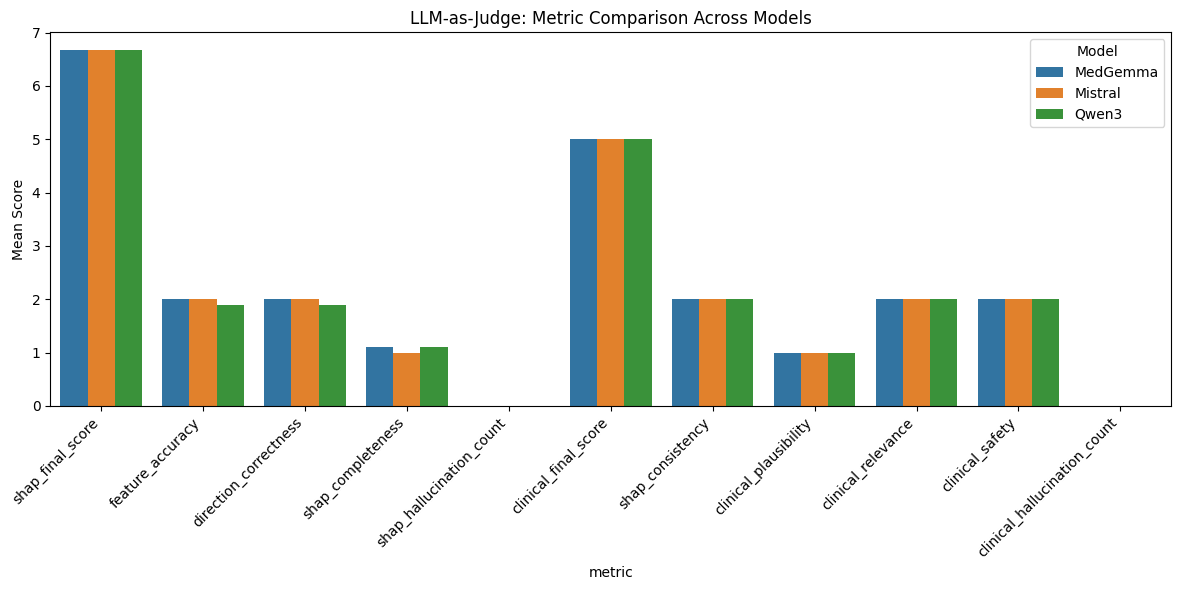

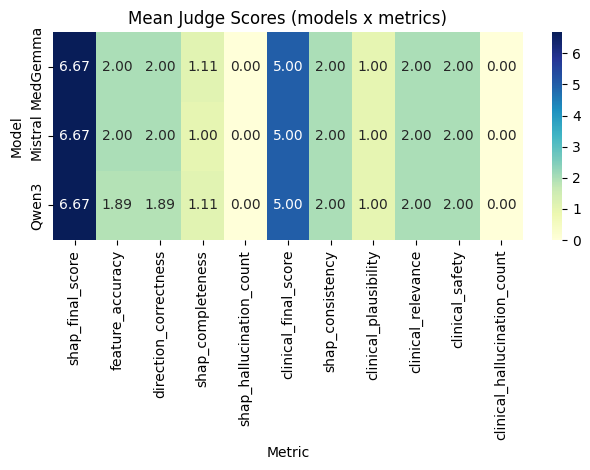

In [64]:
# Compare LLM-as-Judge results across models (MedGemma, Mistral, Qwen3)
files = {
    "MedGemma": "llm_judge_results_medgemma.csv",
    "Mistral": "llm_judge_results_mistral.csv",
    "Qwen3": "llm_judge_results_qwen3.csv"
}

metrics = ["shap_final_score", "clinical_final_score"]

rows = []
for name, path in files.items():
    try:
        df_j = pd.read_csv(path)
    except FileNotFoundError:
        print(f"File not found: {path}")
        continue
    means = df_j[metrics].mean()
    row = {"model": name}
    for m in metrics:
        row[m] = means.get(m, np.nan)
    rows.append(row)

comp = pd.DataFrame(rows)
if comp.empty:
    raise FileNotFoundError("No judge")
# Compare LLM-as-Judge results across models and plot metrics
files = {
    "MedGemma": "llm_judge_results_medgemma.csv",
    "Mistral": "llm_judge_results_mistral.csv",
    "Qwen3": "llm_judge_results_qwen3.csv"
}

# Read files and compute mean per metric
model_means = {}
for name, fname in files.items():
    try:
        dfj = pd.read_csv(fname)
        # keep only numeric columns
        numeric = dfj.select_dtypes(include=[np.number])
        model_means[name] = numeric.mean()
    except FileNotFoundError:
        print(f"File not found: {fname}")
    except Exception as e:
        print(f"Error reading {fname}: {e}")

if not model_means:
    raise RuntimeError("No judge result files loaded.")

# Build comparison DataFrame (metrics x models)
comp_df = pd.DataFrame(model_means).T  # rows = models, cols = metrics
comp_df.index.name = "model"

# Select a sensible subset/order of metrics if present
preferred_metrics = [
    "shap_final_score",
    "feature_accuracy",
    "direction_correctness",
    "shap_completeness",
    "shap_hallucination_count",

    "clinical_final_score",
    "shap_consistency",
    "clinical_plausibility",
    "clinical_relevance",
    "clinical_safety",
    "clinical_hallucination_count"
]
metrics = [m for m in preferred_metrics if m in comp_df.columns]
if not metrics:
    metrics = comp_df.columns.tolist()

# Melt for seaborn
plot_df = comp_df[metrics].reset_index().melt(id_vars="model", var_name="metric", value_name="mean_score")

# Plot grouped barplot
plt.figure(figsize=(12,6))
sns.barplot(data=plot_df, x="metric", y="mean_score", hue="model", ci=None)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean Score")
plt.title("LLM-as-Judge: Metric Comparison Across Models")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

# Optional: heatmap of mean scores (models x metrics)
plt.figure(figsize=(max(6, len(metrics)*0.6), 3 + 0.6*len(model_means)))
sns.heatmap(comp_df[metrics], annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Mean Judge Scores (models x metrics)")
plt.ylabel("Model")
plt.xlabel("Metric")
plt.tight_layout()
plt.show()

# Demo

Threshold Terbaik: 0.5000000000000001 

Accuracy: 0.6666666666666666
Precision: 0.5294117647058824
Recall: 0.6666666666666666
F1 Score: 0.5901639344262295
AUC-ROC: 0.6666666666666667
Mean Absolute Error: 0.3333333333333333
Root Mean Squared Error: 0.5773502691896257


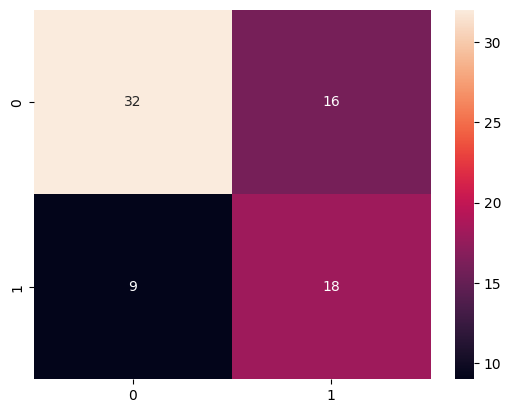

Model saved to: f1_model.pkl
Threshold saved to: best_threshold.json
Optimal Threshold: 0.5000000000000001
Best F1 Score: 0.5901639344262295


In [65]:
import joblib

y_prob = f1_model.predict_proba(X_test_slim)[:, 1]
thresholds = np.arange(0.1, 0.9, 0.05)

best_f1 = 0
best_thresh = 0

for thresh in thresholds:
    y_pred_custom = (y_prob >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_custom)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

final_prediction = (y_prob >= best_thresh).astype(int)
print(f"Threshold Terbaik: {best_thresh} \n")
evaluate_model(y_test, final_prediction)

# Save the model and optimal threshold

# Save the F1 model
model_filename = "f1_model.pkl"
joblib.dump(f1_model, model_filename)

# Save the optimal threshold
threshold_data = {
    "best_threshold": float(best_thresh),
    "best_f1_score": float(best_f1)
}

with open("best_threshold.json", "w") as f:
    json.dump(threshold_data, f)

print(f"Model saved to: {model_filename}")
print(f"Threshold saved to: best_threshold.json")
print(f"Optimal Threshold: {best_thresh}")
print(f"Best F1 Score: {best_f1}")


=== True Positive ===
Original test index : 295
Actual label        : 1
Predicted label     : 1
Probability cancer  : 0.8113

Top positive contributors:
                         feature value     shap
                       Phosphate   8.5 0.534620
                       Magnesium   3.8 0.445964
                         Calcium   2.7 0.256015
Temperature_Upon_presentation_ED  36.9 0.166617
                        Chloride    83 0.133728

Top negative contributors:
                                               feature    value      shap
                                                    DM        1 -0.204290
                                         Active_cancer        0 -0.141374
Patient_receive_vasopressors_inotropes_withinfirst_24h        0 -0.131304
                                      BodyUreaNitrogen Moderate -0.077849
                                      HeartRate_6hours      Low -0.071313


C:\Users\gamin\AppData\Local\Temp\ipykernel_21920\490482676.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="shap", y="feature", palette="viridis")


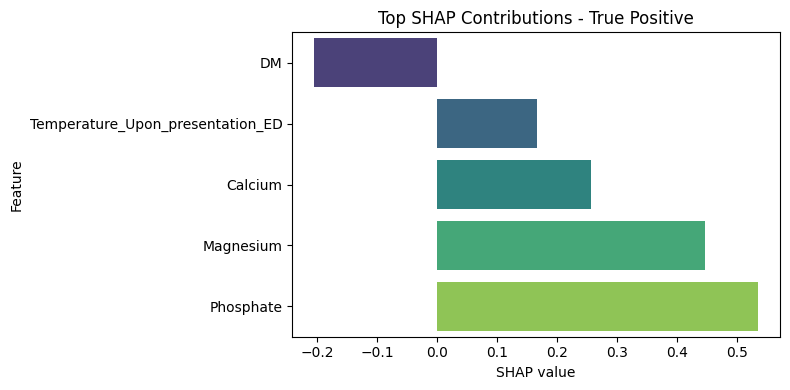

C:\Users\gamin\AppData\Local\Temp\ipykernel_21920\490482676.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="shap", y="feature", palette="viridis")



=== True Negative ===
Original test index : 106
Actual label        : 0
Predicted label     : 0
Probability cancer  : 0.1719

Top positive contributors:
                         feature value     shap
          RespiratoryRate_6hours  26.0 0.118235
                HeartRate_6hours  High 0.101881
                              DM     0 0.071009
IVfluids_requirement_first_24hrs   6.5 0.054786
                             HTN     0 0.025877

Top negative contributors:
                              feature value      shap
                            Phosphate   2.3 -0.481445
                              Calcium   9.5 -0.310662
     Temperature_Upon_presentation_ED  38.0 -0.250982
                  TemperatureT_6hours  39.0 -0.184432
Respiratory_Rate_Upon_presentation_ED  20.0 -0.179356


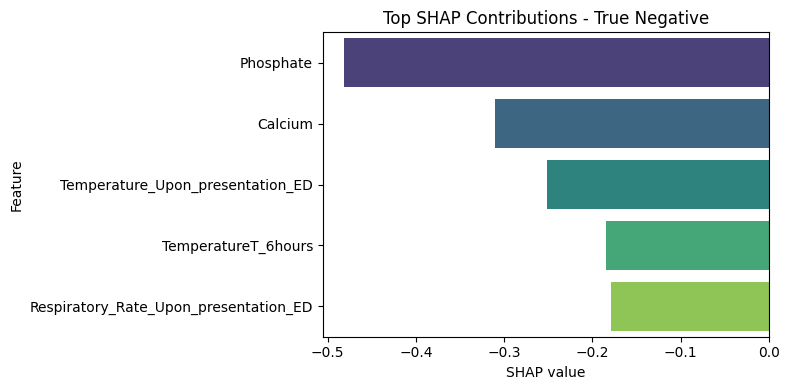


=== False Positive ===
Original test index : 22
Actual label        : 0
Predicted label     : 1
Probability cancer  : 0.6294

Top positive contributors:
                         feature  value     shap
                       Phosphate    4.6 0.414722
Temperature_Upon_presentation_ED   36.4 0.215711
                BodyUreaNitrogen Severe 0.183166
             O2saturation_6hours   94.0 0.161613
          RespiratoryRate_6hours   22.0 0.098435

Top negative contributors:
                                               feature value      shap
Patient_receive_vasopressors_inotropes_withinfirst_24h     0 -0.184607
                                                    DM     1 -0.180290
                                             Magnesium   2.0 -0.165743
                                         Active_cancer     0 -0.160103
                                   TemperatureT_6hours  38.2 -0.130951


C:\Users\gamin\AppData\Local\Temp\ipykernel_21920\490482676.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="shap", y="feature", palette="viridis")


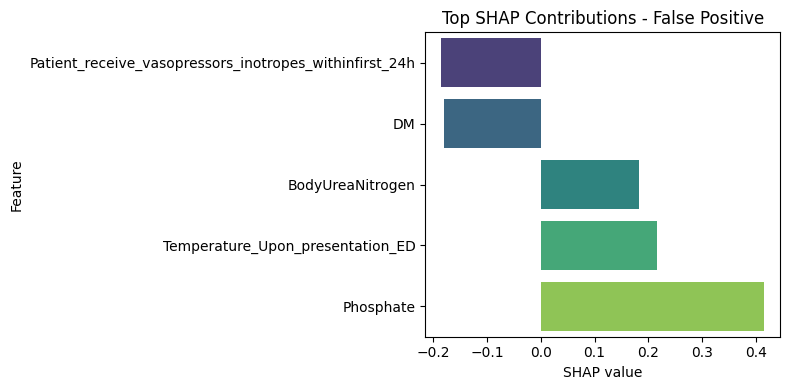


=== False Negative ===

C:\Users\gamin\AppData\Local\Temp\ipykernel_21920\490482676.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="shap", y="feature", palette="viridis")



Original test index : 108
Actual label        : 1
Predicted label     : 0
Probability cancer  : 0.2971

Top positive contributors:
                         feature  value     shap
                         Calcium    7.0 0.278143
             TemperatureT_6hours   36.5 0.159681
                        Chloride     90 0.155407
Temperature_Upon_presentation_ED   36.8 0.117558
                      Creatinine Severe 0.064819

Top negative contributors:
                                               feature value      shap
                                             Phosphate   2.6 -0.547323
                 Respiratory_Rate_Upon_presentation_ED  20.0 -0.187063
Patient_receive_vasopressors_inotropes_withinfirst_24h     0 -0.183721
                                             Magnesium   1.9 -0.171432
                      IVfluids_requirement_first_24hrs   2.5 -0.151555


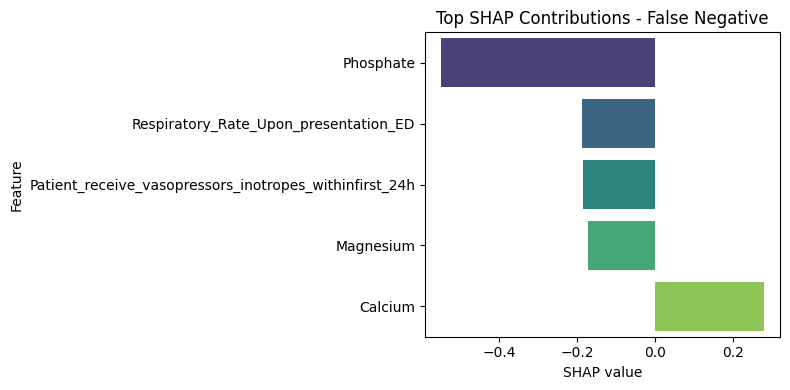

,condition,original_index,actual_label,predicted_label,probability_cancer
0,True Positive,295,1,1,0.811270
1,True Negative,106,0,0,0.171937
2,False Positive,22,0,1,0.629396
3,False Negative,108,1,0,0.297085


In [66]:
# Demo XGBoost pada test data berdasarkan kondisi TP / TN / FP / FN

condition_indices = {
    "True Positive": np.where(tp_condition.to_numpy())[0],
    "True Negative": np.where(tn_condition.to_numpy())[0],
    "False Positive": np.where(fp_condition.to_numpy())[0],
    "False Negative": np.where(fn_condition.to_numpy())[0],
}

def show_case_demo(pos_idx, condition_name, top_n=5):
    original_idx = X_test_slim.index[pos_idx]
    actual_label = int(y_test.iloc[pos_idx])
    predicted_label = int(final_prediction[pos_idx])
    prob_cancer = float(proba_prediction[pos_idx])

    row = X_test_slim.iloc[pos_idx]
    shap_row = shap_values_raw[pos_idx].values

    case_df = pd.DataFrame({
        "feature": X_test_slim.columns,
        "value": row.values,
        "shap": shap_row
    })
    case_df["abs_shap"] = case_df["shap"].abs()
    case_df = case_df.sort_values("abs_shap", ascending=False)

    print(f"\n=== {condition_name} ===")
    print(f"Original test index : {original_idx}")
    print(f"Actual label        : {actual_label}")
    print(f"Predicted label     : {predicted_label}")
    print(f"Probability cancer  : {prob_cancer:.4f}")

    print("\nTop positive contributors:")
    print(
        case_df[case_df["shap"] > 0][["feature", "value", "shap"]]
        .head(top_n)
        .to_string(index=False)
    )

    print("\nTop negative contributors:")
    print(
        case_df[case_df["shap"] < 0][["feature", "value", "shap"]]
        .head(top_n)
        .to_string(index=False)
    )

    plt.figure(figsize=(8, 4))
    plot_df = case_df.head(top_n).sort_values("shap")
    sns.barplot(data=plot_df, x="shap", y="feature", palette="viridis")
    plt.title(f"Top SHAP Contributions - {condition_name}")
    plt.xlabel("SHAP value")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    return {
        "condition": condition_name,
        "original_index": int(original_idx),
        "actual_label": actual_label,
        "predicted_label": predicted_label,
        "probability_cancer": prob_cancer
    }

demo_results = []

for condition_name, idxs in condition_indices.items():
    if len(idxs) == 0:
        print(f"\n=== {condition_name} ===")
        print("Tidak ada contoh pada kondisi ini.")
        continue

    demo_results.append(show_case_demo(idxs[0], condition_name))

demo_df = pd.DataFrame(demo_results)
demo_df